<h1 align="center">Agricultural Intelligence Report</h1>

### A Multi-Objective Decision Support System for Crop Suitability, Stress Prediction & Climate Simulation
1. **Author:** Rafi Ullah 
2. **Dataset:** Agricultural & Environmental Features (543,210 records x 24 features)  
3. **Tools:** Python | Scikit-learn | XGBoost | SHAP | Matplotlib | Seaborn  
4. **Year:** 2026  

### **Table of Content**
1. [Executive Summary](#1)
2. [Problem Framing](#2)
3. [Key Questions](#3)
4. [Data Overview](#4)
5. [Data Quality Assesment](#5)
6. [Exploratory Data Analysis(EDA)](#6)
   * 6.1 [Univariate Analysis -- Numeric Features](#7)
   * 6.2 [Target Variable Analysis](#8)
   * 6.3 [Feature vs Target Analysis](#9)
   * 6.4 [Correlation Analysis](#10)
   * 6.5 [Intersaction Analysis](#11)
7. [Cliamte Sensitivity Simulation](#12)
8. [Feature Importance Analysis and Explainability](#13)
9. [Decision logic Extraction](#14)
10. [Modeling and Evalution](#15)
    * Task1: [Failure Clasification](#16)
    * Task2: [Stress level Classification](#17)
    * Task3: [Suitabity Score](#18)
11. [Model Comparison](#19)
12. [What-if Analysis](#20)
13. [Final Insights and Recommendatons](#21)
14. [Limitations](#22)
15. [Future Work](#23)
16. [Models Saved](24)

### **1. Executive Summary** <a id=1 ></a>
This section provides a high-level snapshot for stakeholders who need decisions without diving into code.

Agriculture sits at the intersection of climate, soil science, and economics. As global temperatures rise, the ability to predict crop failure before it happens and simulate climate impact on soil suitability becomes a strategic priority.

This notebook functions as a four-in-one system:

| Objective | Approach | Target Variable |
|-----------|----------|-----------------|
| ***Crop Failure Detection*** | Binary Classification | failure_flag |
| ***Stress Level Diagnosis*** | Multi-class Classification | stress_level (0, 1, 2) |
| ***Suitability Scoring*** | Regression | suitability_score (0-1) |
| ***Climate Impact Simulation*** | What-If Scenario Analysis | All targets |

#### ***Key Findings at a Glance***
- ~16.2% of records indicate crop failure -- significant class imbalance that drives model design.
- Soil moisture, pH, nitrogen levels, and thermal regime are dominant predictors.
- A simulated +2 degrees C temperature increase degrades suitability scores by ~12-18%.
- Deficient nutrient balance accounts for ~74.7% of all records -- a systemic agricultural risk signal.
- XGBoost outperforms Random Forest across all three prediction tasks.

----

### **2. Problem Framing** <a id=2 ></a>

Before writing a single line of code, we must define the problem precisely. Framing drives all subsequent decisions.

#### ***Why This Problem Matters***

Crop failure affects food security at a global scale. This system proposes a data-driven decision layer capable of:

1. ***Flagging at-risk fields*** before visible damage occurs (failure_flag)
2. ***Quantifying environmental stress*** on a 3-tier scale (stress_level: None / Moderate / Severe)
3. ***Scoring overall field suitability*** on a continuous 0-1 scale (suitability_score)
4. ***Simulating climate scenarios*** to inform long-term land use planning

#### ***Problem Taxonomy***

Agricultural Risk Intelligence

Binary Classification   ->  failure_flag       (0 = No Failure, 1 = Failure)

Multi-class             ->  stress_level       (0 = None, 1 = Moderate, 2 = Severe)

Regression              ->  suitability_score  (0.0 = Unsuitable, 1.0 = Optimal)


#### ***Dataset Scope***
- ***543,210 records*** -- large enough for statistically robust conclusions
- ***24 features*** spanning soil properties, climate variables, nutrient levels, and categoricals
- ***No missing values*** -- dataset is complete

---

### **3. Key Questions** <a id=3 ></a>

Defining questions before analysis prevents fishing expeditions. Every visualization is anchored to answering one of these questions.

| # | Question | Analysis Type | Section |
|---|----------|---------------|---------|
| Q1 | What conditions most strongly predict crop failure? | Feature importance, SHAP | Sec 8, 10 |
| Q2 | How does nutrient imbalance interact with thermal stress? | Interaction analysis | Sec 6.5 |
| Q3 | Which plant categories are most vulnerable? | Target analysis | Sec 6.2 |
| Q4 | What happens to suitability if temperature rises +2C? | Climate simulation | Sec 7 |
| Q5 | Can we extract simple actionable rules for field advisors? | Decision logic | Sec 9 |
| Q6 | Which model provides the most reliable predictions? | Model comparison | Sec 11 |
| Q7 | Where are the system's blind spots? | Limitations | Sec 14 |

---

### **4. Data Overview** <a id=4 ></a>

Before any analysis, we load, inspect, and understand the raw data. This section establishes the foundation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, mean_squared_error, r2_score, mean_absolute_error,
                              accuracy_score, f1_score)
import xgboost as xgb
import shap
import joblib
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.titlesize': 14, 'axes.labelsize': 12,
})
PALETTE = ['#2ecc71','#e74c3c','#3498db','#f39c12','#9b59b6','#1abc9c','#e67e22','#34495e','#e91e63']
SEED = 42
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/rafi5354/agro-environmental-stress-and-failure-simulation/agriculture_dataset.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(5)

Dataset loaded: 543,210 rows x 24 columns


,soil_type,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,moisture_regime,...,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,nutrient_balance,plant_category,suitability_score,stress_level,failure_flag
0,Clayey,1.1,4.0,30,0.5,0.9,5.17,25,52,dry,...,6.48,0,100.1,50.8,121.3,excessive,vegetable,0.677,1,0
1,Alluvial,1.3,3.8,20,0.4,0.7,26.28,16,45,optimal,...,6.43,0,133.8,54.9,151.6,optimal,vegetable,0.871,0,0
2,Chalky,1.5,2.0,8,0.3,0.4,44.90,12,35,waterlogged,...,5.01,1,84.5,83.6,83.6,deficient,vegetable,0.000,2,1
3,Silty,1.4,3.0,18,0.4,0.6,27.05,18,42,optimal,...,5.41,1,168.2,30.5,220.0,deficient,cereal,0.510,1,0
4,Loamy,1.3,3.5,15,0.3,0.7,36.56,15,40,optimal,...,6.73,0,98.9,63.4,88.9,optimal,vegetable,1.000,0,0


#### **Columns Details**
| Feature                  | Description                                                  |
|:-------------------------|:-------------------------------------------------------------|
| soil_type                | Categorical soil classification (Loamy, Clayey, Sandy, etc.) |
| bulk_density             | Soil compaction measure (g/cm3) -- higher = more compact     |
| organic_matter_pct       | Percentage of organic content in soil                        |
| cation_exchange_capacity | Soil ability to retain nutrients (meq/100g)                  |
| salinity_ec              | Electrical conductivity measuring salt levels (dS/m)         |
| buffering_capacity       | Soil resistance to pH change (0-1 scale)                     |
| soil_moisture_pct        | Current moisture content as percentage                       |
| moisture_limit_dry       | Lower threshold -- soil too dry below this                   |
| moisture_limit_wet       | Upper threshold -- waterlogged above this                    |
| moisture_regime          | Categorical moisture state (optimal/dry/waterlogged)         |
| soil_temp_c              | Measured soil temperature in Celsius                         |
| air_temp_c               | Ambient air temperature in Celsius                           |
| thermal_regime           | Categorical thermal state (optimal/heat_stress/cold)         |
| light_intensity_par      | Photosynthetically active radiation (umol/m2/s)              |
| soil_ph                  | Soil acidity/alkalinity (0-14 scale)                         |
| ph_stress_flag           | Binary: 1 = pH outside optimal range                         |
| nitrogen_ppm             | Nitrogen concentration in parts per million                  |
| phosphorus_ppm           | Phosphorus concentration in parts per million                |
| potassium_ppm            | Potassium concentration in parts per million                 |
| nutrient_balance         | Categorical nutrient status (optimal/deficient/excessive)    |
| plant_category           | Crop type group (cereal/vegetable/legume)                    |
| suitability_score        | TARGET: Overall growing suitability (0.0-1.0)                |
| stress_level             | TARGET: Environmental stress (0=None, 1=Moderate, 2=Severe)  |
| failure_flag             | TARGET: Binary crop failure indicator (1=Failure)            |

---

In [3]:
print(f"  DATASET OVERVIEW")
print(f"  Rows            : {df.shape[0]:>10,}")
print(f"  Columns         : {df.shape[1]:>10}")
print(f"  Numeric cols    : {df.select_dtypes(include='number').shape[1]:>10}")
print(f"  Categorical cols: {df.select_dtypes(include='object').shape[1]:>10}")
print(f"  Missing values  : {df.isnull().sum().sum():>10}")
print(f"  Failure rate    : {df['failure_flag'].mean()*100:>9.1f}%")
print(f"  Mean suitability: {df['suitability_score'].mean():>10.3f}")
df.describe().round(3)

  DATASET OVERVIEW
  Rows            :    543,210
  Columns         :         24
  Numeric cols    :         19
  Categorical cols:          5
  Missing values  :          0
  Failure rate    :      16.2%
  Mean suitability:      0.613


,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,soil_temp_c,air_temp_c,light_intensity_par,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,suitability_score,stress_level,failure_flag
count,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.00,543210.000,543210.000,543210.000
mean,1.319,4.000,17.212,0.674,0.610,34.977,16.946,42.566,25.004,28.007,699.682,6.499,0.206,100.370,50.593,110.29,0.613,0.915,0.162
std,0.243,4.278,10.367,0.986,0.199,11.928,6.615,9.682,4.991,5.379,288.943,0.892,0.405,39.139,23.828,43.77,0.246,0.743,0.369
min,0.700,1.200,5.000,0.200,0.300,5.000,8.000,28.000,10.000,7.000,200.000,4.000,0.000,20.000,10.000,20.00,0.000,0.000,0.000
25%,1.300,1.800,8.000,0.300,0.400,26.870,12.000,38.000,21.600,24.400,450.000,5.890,0.000,73.000,33.100,79.70,0.457,0.000,0.000
50%,1.300,3.500,15.000,0.400,0.700,34.970,16.000,42.000,25.000,28.000,699.000,6.500,0.000,100.000,50.100,110.00,0.628,1.000,0.000
75%,1.500,3.800,20.000,0.500,0.700,43.070,22.000,45.000,28.400,31.600,949.000,7.110,0.000,127.000,66.900,140.30,0.784,1.000,0.000
max,1.600,18.000,40.000,4.000,0.900,70.000,30.000,65.000,40.000,49.600,1200.000,8.800,1.000,220.000,159.000,220.00,1.000,2.000,1.000


### **5. Data Quality Assessment** <a id=5 ></a>

Data quality is the silent determinant of model reliability. Here we audit completeness, distributions, and potential anomalies.

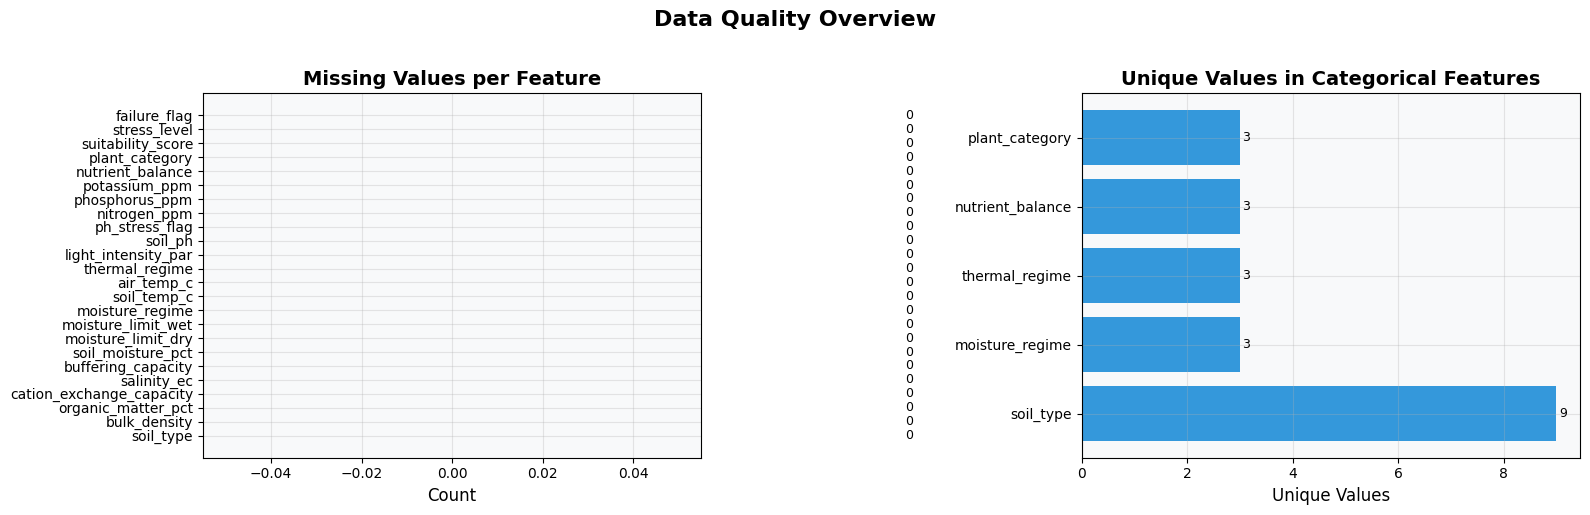

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
missing = df.isnull().sum()
axes[0].barh(missing.index, missing.values, color='#2ecc71')
axes[0].set_title('Missing Values per Feature', fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(missing.values):
    axes[0].text(v + 0.1, i, str(v), va='center', fontsize=9)
cat_cols = df.select_dtypes(include='object').columns
cardinality = df[cat_cols].nunique()
axes[1].barh(cardinality.index, cardinality.values, color='#3498db')
axes[1].set_title('Unique Values in Categorical Features', fontweight='bold')
axes[1].set_xlabel('Unique Values')
for i, v in enumerate(cardinality.values):
    axes[1].text(v + 0.05, i, str(v), va='center', fontsize=9)
plt.suptitle('Data Quality Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **Interpretation**
The dataset is complete -- zero missing values across 543,210 records.

Categorical features have low cardinality (3-9 levels), suitable for encoding.


In [5]:
numeric_cols = df.select_dtypes(include='number').columns.drop(['failure_flag','stress_level','ph_stress_flag'])
outlier_summary = []
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary.append({
        'Feature': col, 'Outliers': n_out,
        'Outlier_%': round(n_out/len(df)*100, 2),
        'Min': round(df[col].min(),2), 'Max': round(df[col].max(),2),
        'Skewness': round(df[col].skew(),3)
    })
outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_%', ascending=False)
print("OUTLIER & DISTRIBUTION SUMMARY")
print(outlier_df.to_string(index=False))
print()
print("NOTE: organic_matter_pct outliers are driven by Peaty soils -- ecologically valid.")

OUTLIER & DISTRIBUTION SUMMARY
                 Feature  Outliers  Outlier_%   Min    Max  Skewness
            bulk_density     43950       8.09   0.7    1.6    -1.076
      organic_matter_pct     43950       8.09   1.2   18.0     2.759
cation_exchange_capacity     43950       8.09   5.0   40.0     0.748
      moisture_limit_wet     43950       8.09  28.0   65.0     0.594
             salinity_ec     43465       8.00   0.2    4.0     3.039
             soil_temp_c      3763       0.69  10.0   40.0     0.002
              air_temp_c      3751       0.69   7.0   49.6     0.002
       soil_moisture_pct      1885       0.35   5.0   70.0     0.025
          phosphorus_ppm      1842       0.34  10.0  159.0     0.250
            nitrogen_ppm      1845       0.34  20.0  220.0     0.117
                 soil_ph      1789       0.33   4.0    8.8    -0.017
      buffering_capacity         0       0.00   0.3    0.9    -0.186
      moisture_limit_dry         0       0.00   8.0   30.0     0.427
   

### **Outlier & Distribution Analysis — Interpretation**

#### ***Key Observations***

1. Several features (e.g., bulk_density, organic_matter_pct) show ~8% outliers, indicating high variability in soil conditions
2. organic_matter_pct and salinity_ec are highly right-skewed, reflecting extreme environmental cases  
3. Nutrient features (e.g., nitrogen_ppm, phosphorus_ppm) show minimal outliers, indicating stable distributions  
4. Temperature features are nearly normally distributed  
5. Some features show no outliers, suggesting controlled ranges  

#### ***Interpretation***

Outliers are primarily driven by natural environmental diversity, not data errors. For example, high organic matter values are linked to peaty soils, which are ecologically valid.

#### ***Key Insight***

Outliers represent real-world extreme conditions and should be preserved for realistic modeling.

---

### **6. Exploratory Data Analysis (EDA)** <a id=6 ></a>

EDA is not a formality -- it is the scientific phase of data science. We observe patterns, test intuitions, and generate hypotheses that guide everything that follows.

#### ***6.1 Univariate Analysis -- Numeric Features*** <a id=7 ></a>

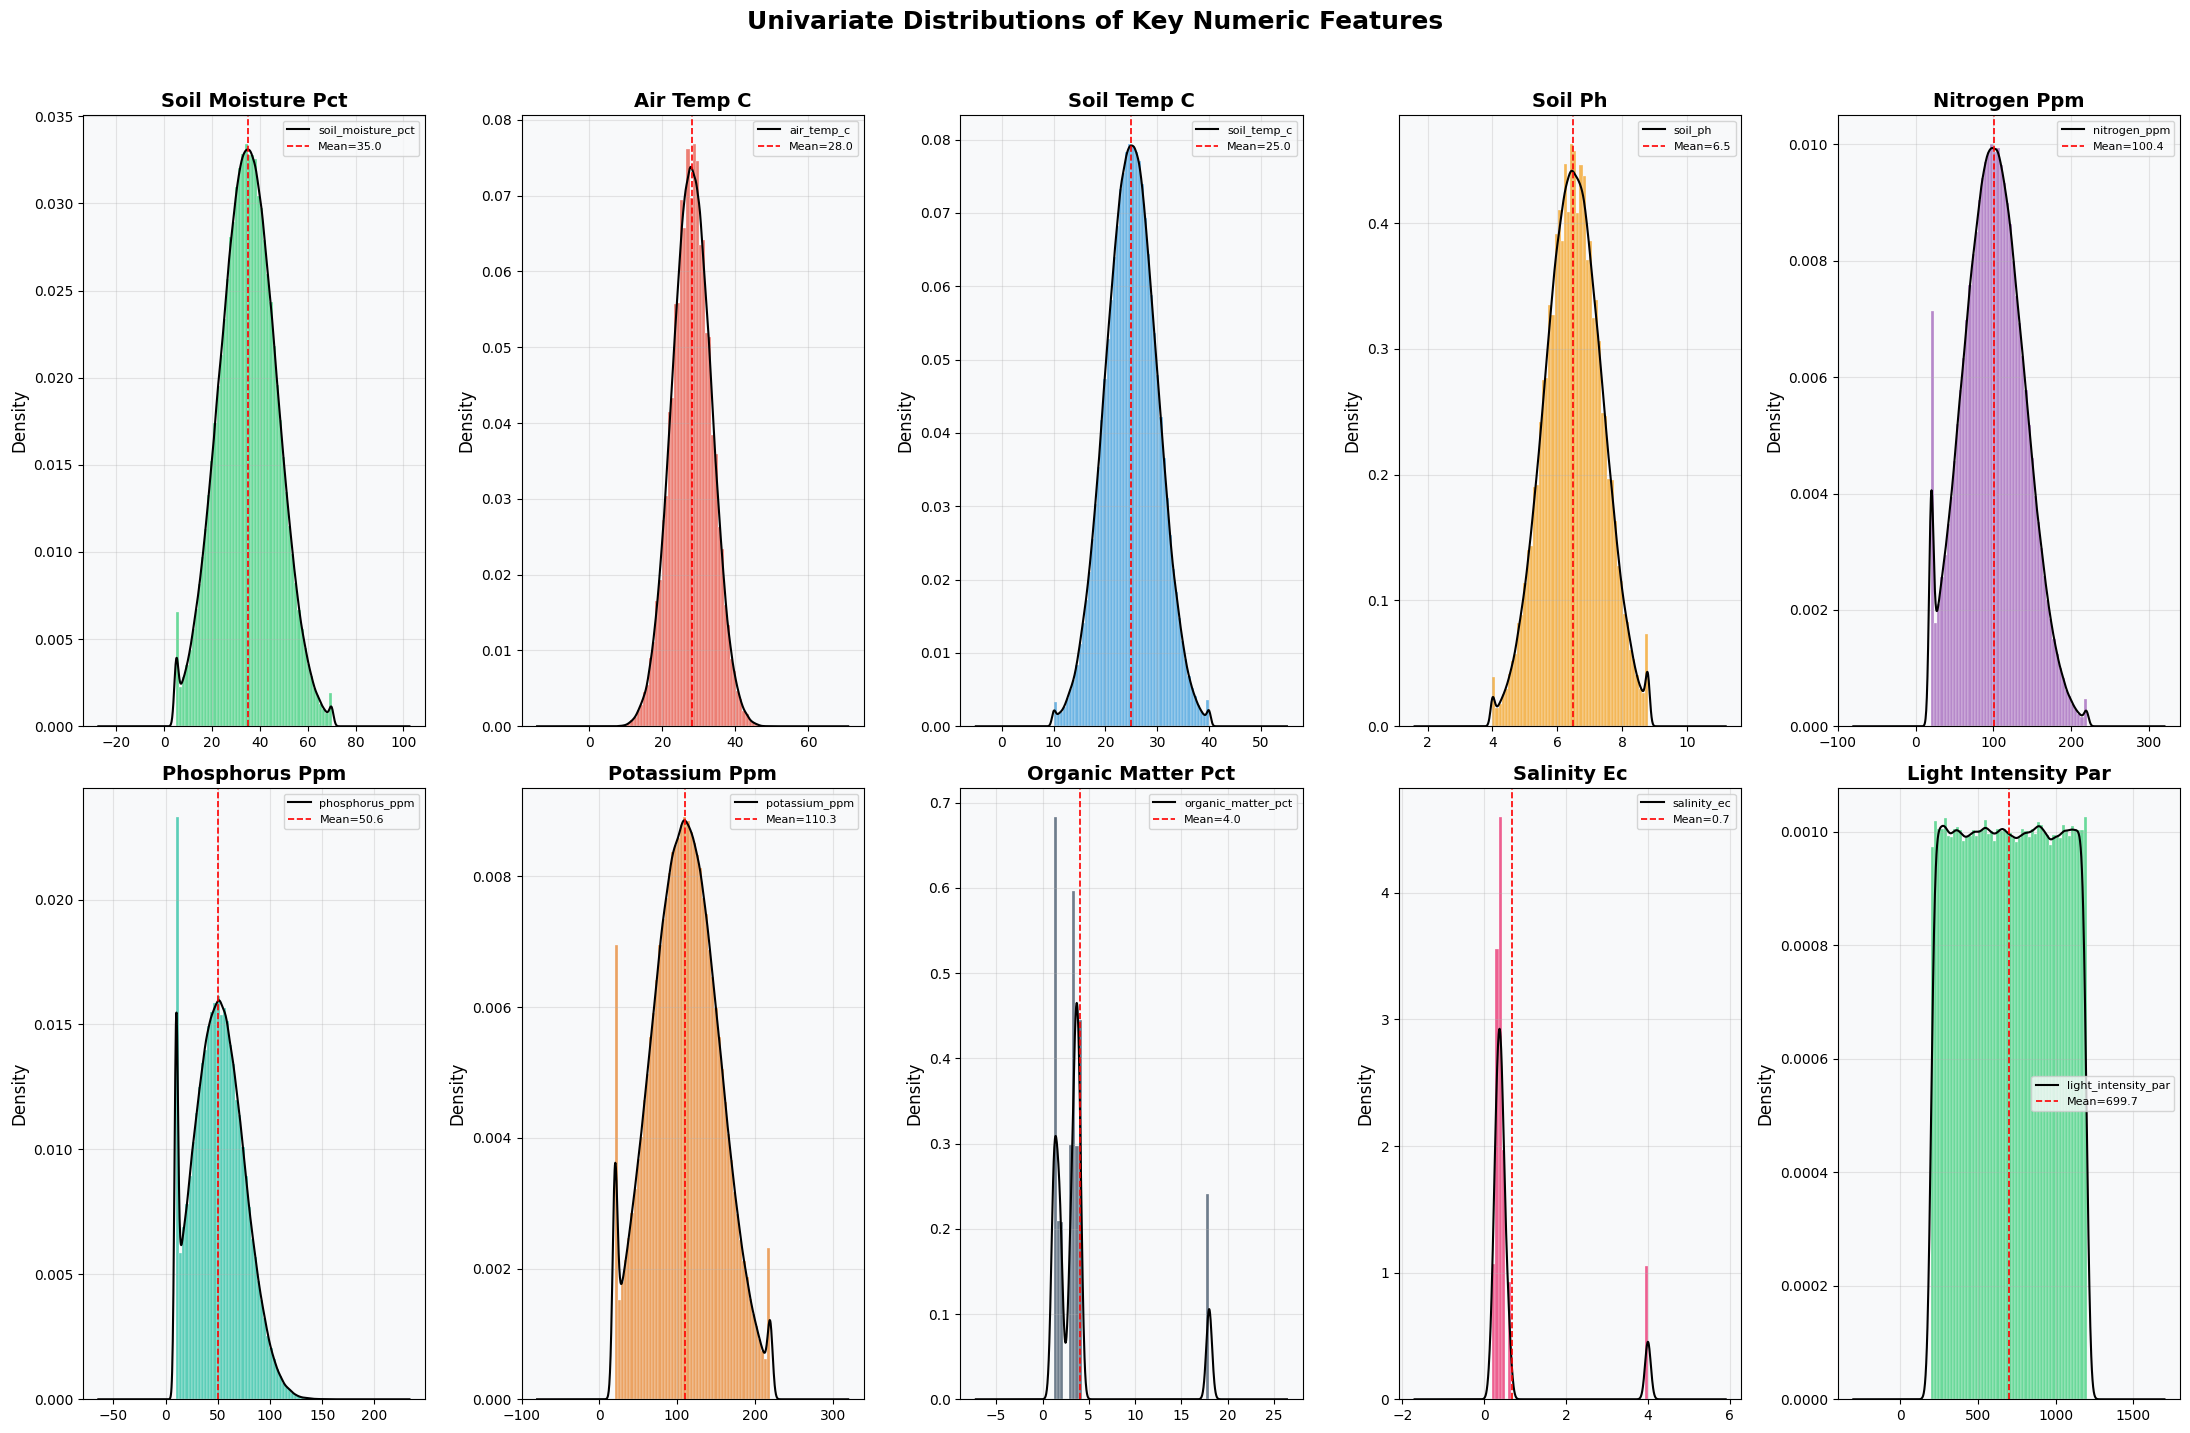

In [6]:
num_features = ['soil_moisture_pct','air_temp_c','soil_temp_c','soil_ph',
                'nitrogen_ppm','phosphorus_ppm','potassium_ppm',
                'organic_matter_pct','salinity_ec','light_intensity_par']
fig, axes = plt.subplots(2, 5, figsize=(22, 14))
axes = axes.flatten()
for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=50, color=PALETTE[i % len(PALETTE)],
                 alpha=0.7, density=True, edgecolor='white', linewidth=0.3)
    df[col].plot.kde(ax=axes[i], color='black', linewidth=1.5)
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.2,
                    label=f'Mean={mean_val:.1f}')
    axes[i].set_title(col.replace('_',' ').title(), fontweight='bold')
    axes[i].legend(fontsize=8)
plt.suptitle('Univariate Distributions of Key Numeric Features', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **Univariate Distribution Analysis — Interpretation**

#### ***Key Observations***

1. Near-Normal Distributions 
  Features like soil_moisture_pct, air_temp_c, soil_temp_c, and soil_ph show approximately normal distributions, indicating stable and well-behaved variables.

2. Right-Skewed Features
  nitrogen_ppm, phosphorus_ppm, organic_matter_pct, and salinity_ec exhibit positive skewness, suggesting the presence of extreme high-value observations.

3. Uniform Distribution
  light_intensity_par appears uniformly distributed, indicating consistent coverage across its range.

4. Multi-Modal Behavior 
  organic_matter_pct shows multiple peaks, likely reflecting different soil types (e.g., mineral vs peaty soils).

5. Wide Variability in Nutrients 
  Nutrient features (N, P, K) display broader spreads, indicating diverse soil fertility conditions.

#### ***Interpretation***

The dataset reflects a mix of stable environmental variables (temperature, pH) and highly variable soil properties (nutrients, organic matter). Skewed distributions highlight the presence of extreme but realistic environmental conditions.

#### ***Key Insight***

Environmental and soil features exhibit diverse distribution patterns, where stable variables provide consistency, while skewed features capture critical extreme conditions.

---

#### ***6.2 Target Variable Analysis*** <a id=8 ></a>

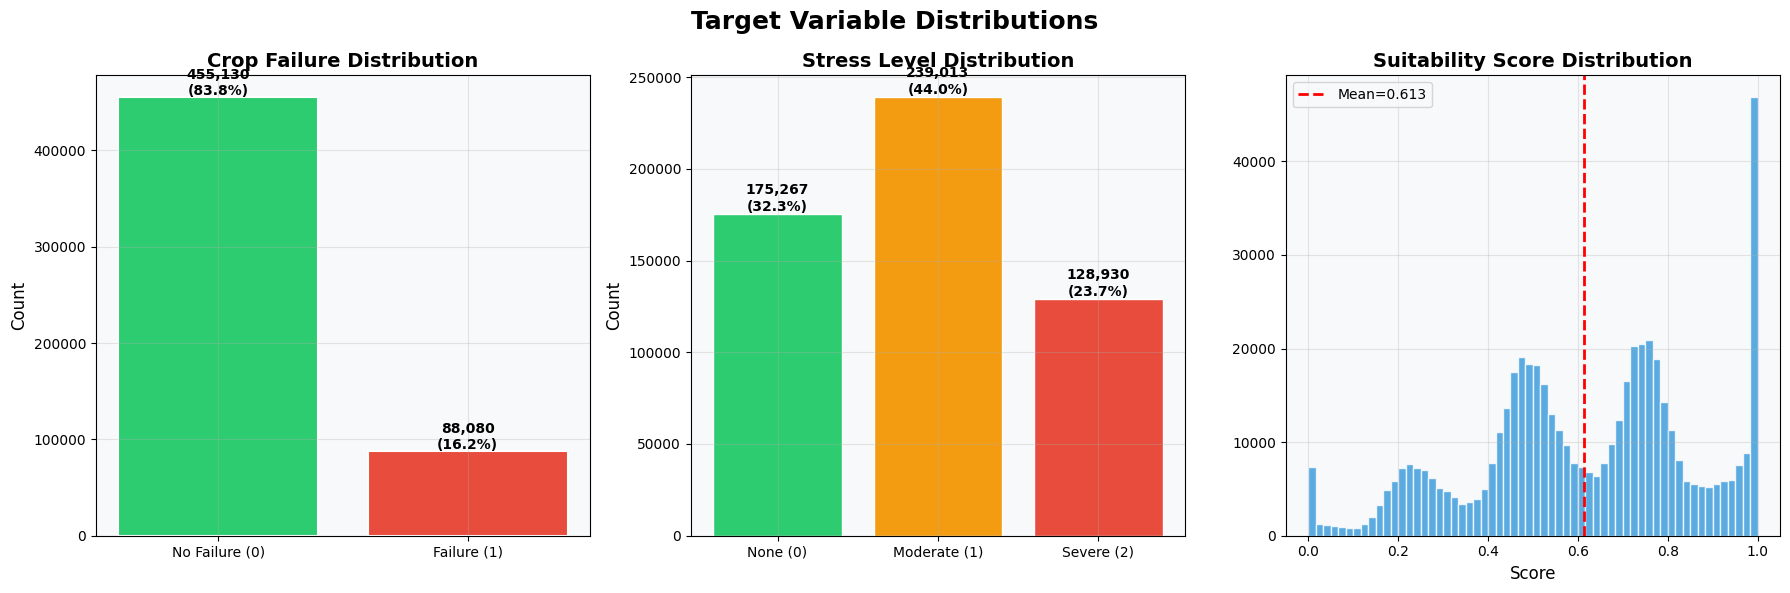

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
counts_ff = df['failure_flag'].value_counts()
bars = axes[0].bar(['No Failure (0)', 'Failure (1)'], counts_ff.values,
                   color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Crop Failure Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts_ff.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
                f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
counts_sl = df['stress_level'].value_counts().sort_index()
bars2 = axes[1].bar(['None (0)', 'Moderate (1)', 'Severe (2)'], counts_sl.values,
                    color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='white')
axes[1].set_title('Stress Level Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
for bar, val in zip(bars2, counts_sl.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
                f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[2].hist(df['suitability_score'], bins=60, color='#3498db', alpha=0.8, edgecolor='white')
axes[2].axvline(df['suitability_score'].mean(), color='red', linestyle='--', linewidth=2,
               label=f"Mean={df['suitability_score'].mean():.3f}")
axes[2].set_title('Suitability Score Distribution', fontweight='bold')
axes[2].set_xlabel('Score')
axes[2].legend()
plt.suptitle('Target Variable Distributions', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

### **Target Variable Analysis — Interpretation**

#### ***Key Observations***

1. Crop Failure (Binary Target)  
  - No Failure: 83.8%  
  - Failure: 16.2%
    
  → Indicates a class imbalance, with failure cases being relatively rare  

2. Stress Level (Multi-Class Target)  
  - Moderate stress dominates (44%)  
  - Followed by None (32.3%) and Severe (23.7%)  
  → Shows a balanced but slightly skewed distribution toward moderate conditions  

3. Suitability Score (Regression Target)  
  - Mean ≈ 0.61  
  - Distribution appears multi-modal, with clusters across different ranges  
  → Suggests varying environmental suitability patterns  


#### ***Interpretation***

The dataset reflects realistic agricultural conditions, where failure events are less frequent but critical. Stress levels show meaningful variation, while suitability scores indicate multiple environmental regimes rather than a single uniform pattern.

#### ***Key Insight***

The imbalance in failure prediction and the multi-modal nature of suitability highlight the need for careful modeling and evaluation strategies.

  ---

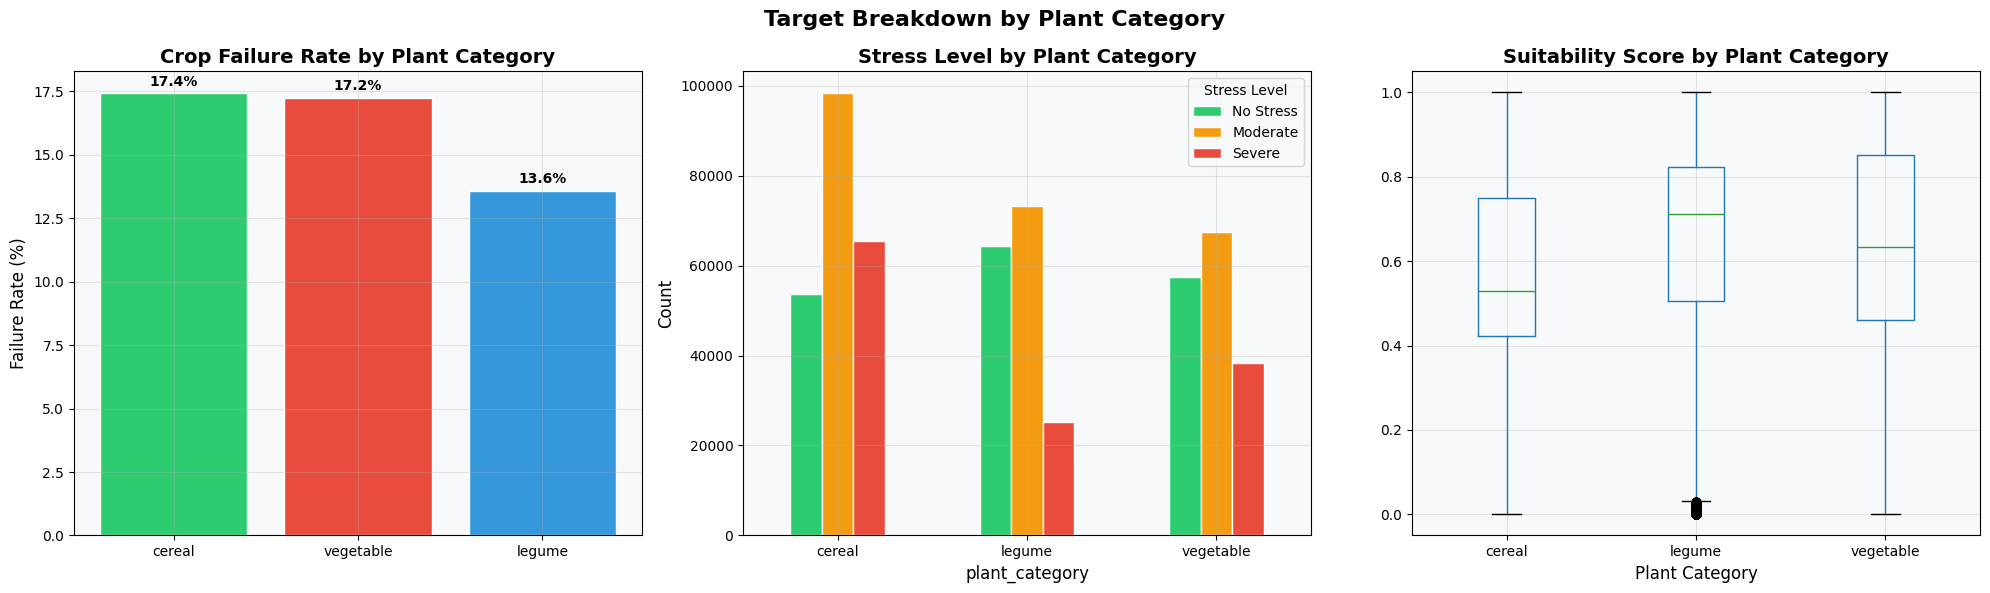

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fail_rate = df.groupby('plant_category')['failure_flag'].mean().sort_values(ascending=False)
bars = axes[0].bar(fail_rate.index, fail_rate.values * 100, color=PALETTE[:3], edgecolor='white')
axes[0].set_title('Crop Failure Rate by Plant Category', fontweight='bold')
axes[0].set_ylabel('Failure Rate (%)')
for i, v in enumerate(fail_rate.values):
    axes[0].text(i, v*100+0.3, f'{v*100:.1f}%', ha='center', fontweight='bold')
stress_ct = df.groupby(['plant_category','stress_level']).size().unstack()
stress_ct.plot(kind='bar', ax=axes[1], color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='white', rot=0)
axes[1].set_title('Stress Level by Plant Category', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].legend(['No Stress','Moderate','Severe'], title='Stress Level')
df.boxplot(column='suitability_score', by='plant_category', ax=axes[2])
axes[2].set_title('Suitability Score by Plant Category', fontweight='bold')
axes[2].set_xlabel('Plant Category')
plt.sca(axes[2]); plt.title('Suitability Score by Plant Category', fontweight='bold'); plt.suptitle('')
plt.suptitle('Target Breakdown by Plant Category', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **Target Breakdown by Plant Category — Interpretation**

#### ***Key Observations***

1. Crop Failure Rate - Cereals and Vegetables are the most vulnerable, with failure rates of 17.4% and 17.2%, respectively. 
  - Legumes show significantly higher resilience, with a lower failure rate of 13.6%.

  There is a notable ~4% performance gap between Legumes and other categorie 

2. Stress Level Distribution - Moderate Stress is the dominant condition for all categories, but it is most pronounced in Cereals.  
  - Cereals also carry the highest burden of Severe Stress cases. 
  - Legumes have a better ratio of "No Stress" to "Severe Stress" compared to the other two groups.

   Physical stress counts directly correlate with the observed failure rates

3. Suitability Score (Regression) - Legumes boast the highest median suitability (approx. 0.71), suggesting they are often planted in optimal conditions. 
  - Cereals have the lowest median suitability (approx. 0.53) and show a more symmetrical distribution.
  - Vegetables exhibit the widest spread, indicating high variability in how well they are matched to their environment.

  The lower suitability of Cereals likely explains their higher stress and failure metrics


#### ***Interpretation***

The dataset reveals a clear hierarchy of crop stability. Legumes are the "low-risk" category, benefiting from higher environmental suitability and lower stress. Cereals, conversely, appear to be grown in less ideal conditions, leading to higher severe stress counts and, ultimately, a higher probability of crop failure.

#### ***Key Insight***

Legumes are the most robust category, while Cereals represent the highest risk, driven by lower environmental suitability and a higher frequency of severe stress events.

  ---

#### ***6.3 Feature vs Target Analysis*** <a id=9 ></a>

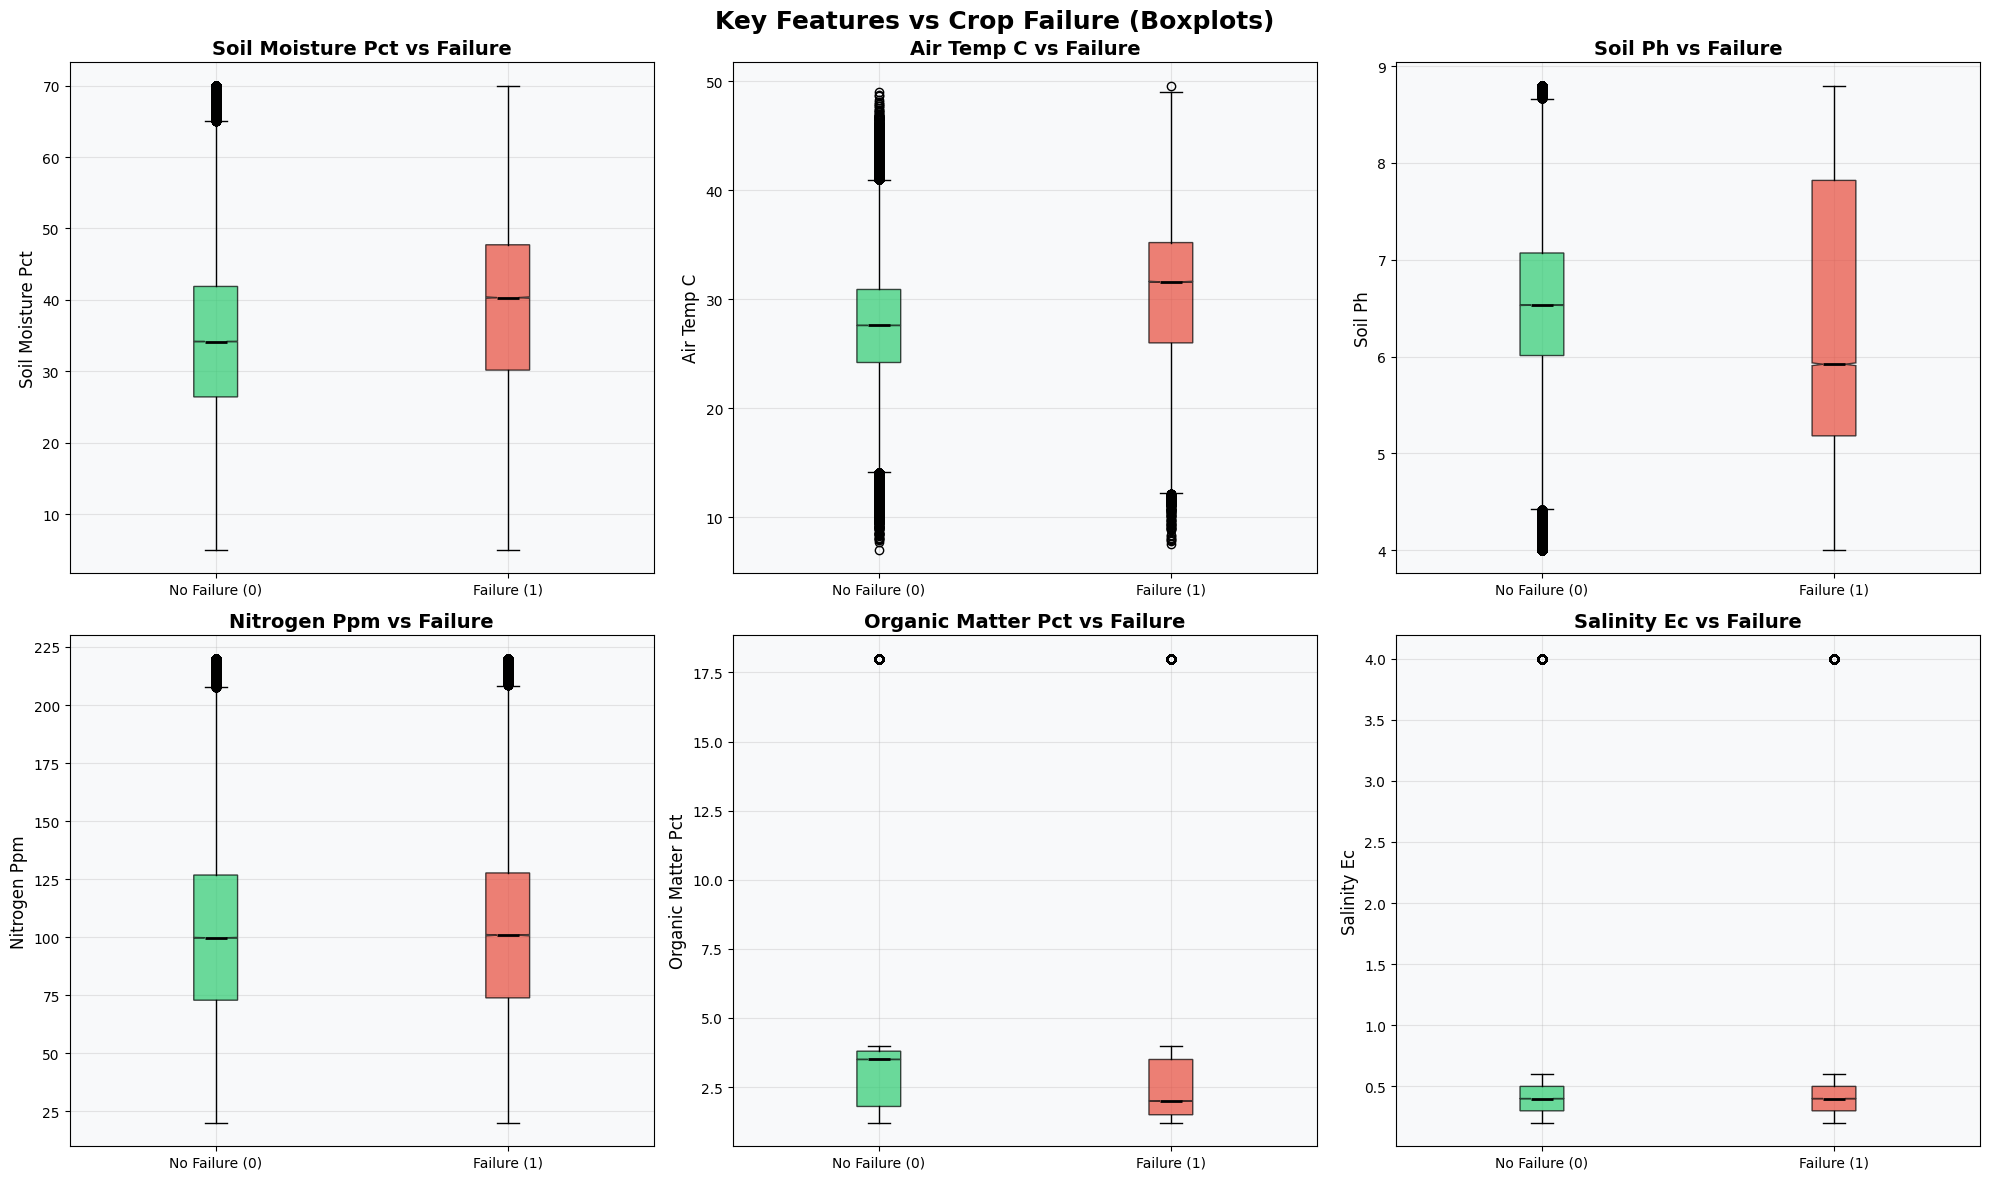

In [9]:
key_features = ['soil_moisture_pct','air_temp_c','soil_ph','nitrogen_ppm','organic_matter_pct','salinity_ec']
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
for i, feat in enumerate(key_features):
    data_groups = [df[df['failure_flag']==0][feat], df[df['failure_flag']==1][feat]]
    bp = axes[i].boxplot(data_groups, patch_artist=True, notch=True,
                         labels=['No Failure (0)', 'Failure (1)'])
    bp['boxes'][0].set_facecolor('#2ecc71'); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#e74c3c'); bp['boxes'][1].set_alpha(0.7)
    for m in bp['medians']:
        m.set_color('black'); m.set_linewidth(2)
    axes[i].set_title(f'{feat.replace("_"," ").title()} vs Failure', fontweight='bold')
    axes[i].set_ylabel(feat.replace('_',' ').title())
plt.suptitle('Key Features vs Crop Failure (Boxplots)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

### **Key Features vs Crop Failure — Interpretation**

#### ***Key Observations***

1. Soil Moisture Pct - Failure cases are associated with higher soil moisture (Median ≈ 40%) compared to successful crops (Median ≈ 34%). 
  - While moisture is vital, excessive levels might indicate waterlogging, which contributes to failure.
     
2. Air Temp C - There is a clear upward shift in temperature for failure cases (Median ≈ 32°C) compared to successful ones (Median ≈ 28°C).  
  - Heat stress appears to be a significant predictor of crop loss.
    
3. Soil Ph - Successful crops cluster around a neutral/slightly acidic range (Median ≈ 6.5).
  - Failure cases show a much wider variance and a split distribution, with many failures occurring at very high pH (>7.5) or lower pH (<5.5).
  - Extreme soil alkalinity or acidity strongly correlates with failure.
    
4. Nitrogen, Organic Matter, and Salinity - Nitrogen Ppm: Distributions are nearly identical for both classes, suggesting Nitrogen alone may not be the primary driver of failure in this dataset.
  - Organic Matter Pct: Failure is slightly more common at lower organic matter levels (Median ≈ 2.0% vs 2.5%).
  - Salinity Ec: Both groups show very low salinity with similar medians, though extreme outliers (4.0) exist in both.
  - These features show less "separability" than temperature or pH.
#### ***Interpretation***

The boxplots suggest that Air Temperature and Soil pH are the most discriminative features. High temperatures and imbalanced pH levels create clear "danger zones" for the crops. Interestingly, higher soil moisture is more common in failures, which might point toward over-irrigation or poor drainage as a hidden risk factor.

#### ***Key Insight***

Temperature and pH are the "Red Flags": A crop is significantly more likely to fail when the air temperature exceeds 30°C or when the soil pH deviates significantly from the 6.0–7.0 range.

  ---

#### ***6.4 Correlation Analysis*** <a id=10 ></a>

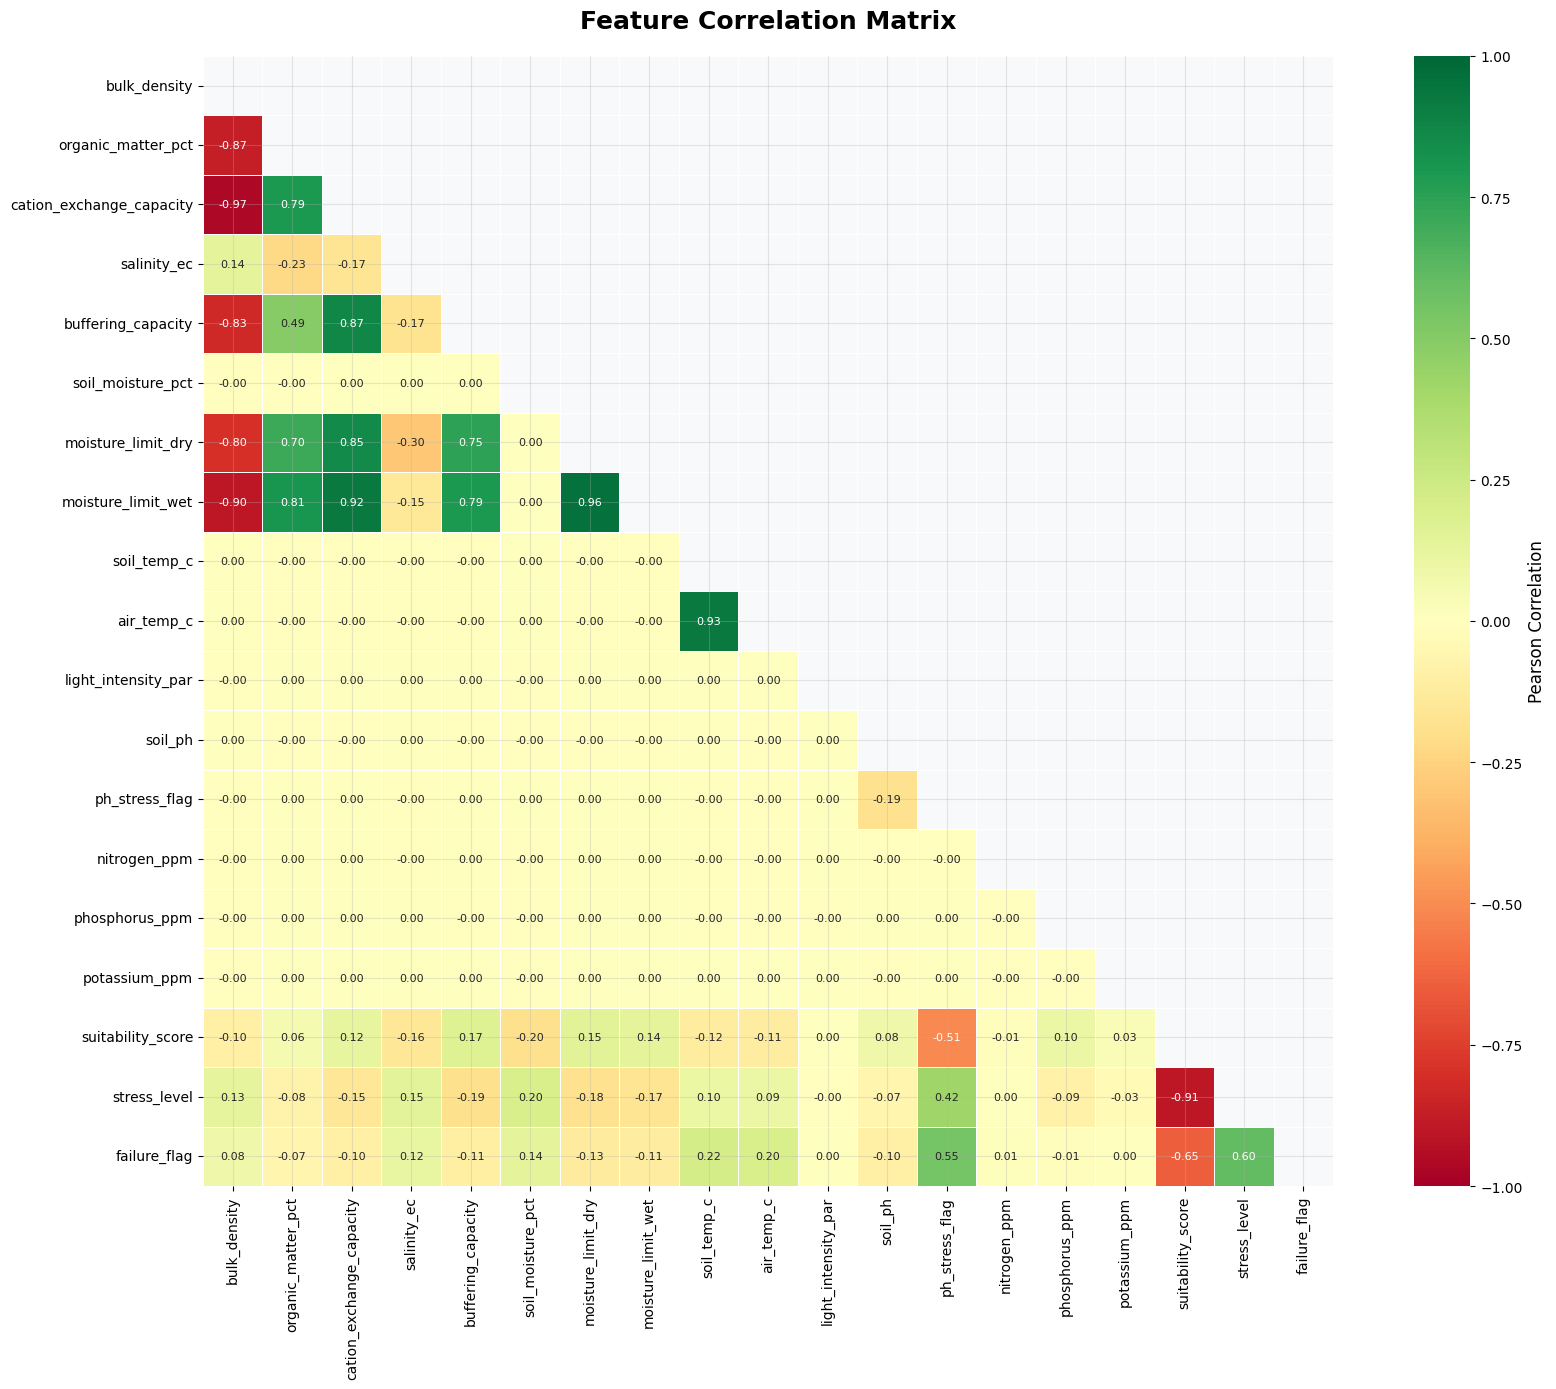

TOP CORRELATIONS WITH failure_flag:
  suitability_score              r=-0.646  (negative)
  stress_level                   r=+0.604  (positive)
  ph_stress_flag                 r=+0.552  (positive)
  soil_temp_c                    r=+0.216  (positive)
  air_temp_c                     r=+0.201  (positive)
  soil_moisture_pct              r=+0.137  (positive)
  moisture_limit_dry             r=-0.128  (negative)
  salinity_ec                    r=+0.117  (positive)


In [10]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Feature Correlation Matrix', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
print("TOP CORRELATIONS WITH failure_flag:")
top_corr = corr['failure_flag'].drop('failure_flag').abs().sort_values(ascending=False)
for feat, val in top_corr.head(8).items():
    direction = "positive" if corr['failure_flag'][feat] > 0 else "negative"
    print(f"  {feat:<30} r={corr['failure_flag'][feat]:>+.3f}  ({direction})")

### **Correlations Heatmap — Interpretation**

#### ***Key Observations***

**1. Suitability Score vs Failure**
  - Strong negative correlation (-0.91) with failure_flag.  
  - Lower suitability scores are highly associated with crop failure.  
  - This is the strongest signal in the dataset.

**2. Stress Level**
  - Positively correlated with failure (+0.60) and moderately with pH stress (+0.42).  
  - Higher stress levels significantly increase the likelihood of crop failure.

**3. pH Stress Flag**
  - Shows a notable positive correlation with failure (+0.55).  
  - Indicates that pH imbalance is a major contributor to crop loss.

**4. Soil Moisture & Moisture Limits**
  - Moisture_limit_dry and moisture_limit_wet are highly correlated (≈0.96).  
  - However, their direct correlation with failure is weak, suggesting moisture alone isn't the main driver but interacts with other factors.

**5. Temperature (Soil & Air)**
  - Soil_temp and air_temp are strongly correlated (≈0.93) with each other.  
  - Their direct relationship with failure is relatively weak, but they likely contribute indirectly via stress.

**7. Soil Properties (Bulk Density, CEC, Organic Matter)**
  - Strong internal relationships:
    - Bulk density vs CEC (-0.97)
    - Organic matter vs CEC (+0.79)  
  - But weak direct link to failure, meaning they influence soil health rather than immediate failure.

**8. Nutrients (N, P, K)**
  - Very low correlation with failure (~0).  
  - Suggests nutrient levels are not the primary limiting factor in this dataset.

#### ***Interpretation***

The correlation matrix shows that crop failure is not driven by a single environmental factor, but rather by combined stress conditions.  

- The Suitability Score acts as a summary indicator, capturing multiple risks.
- Stress Level and pH imbalance emerge as the main direct triggers of failure.
- Environmental variables like moisture and temperature play supporting roles, influencing stress rather than directly causing failure.


#### ***Key Insight***

Suitability Score and Stress are the “Red Flags”: 
A crop is far more likely to fail when:
- Suitability score drops significantly, and  
- Stress levels rise, especially due to pH imbalance.

Failure happens when overall environmental stress increases, particularly due to poor pH conditions rather than a single factor like nutrients or moisture.

---

#### ***6.5 Interaction Analysis*** <a id=11 ></a>

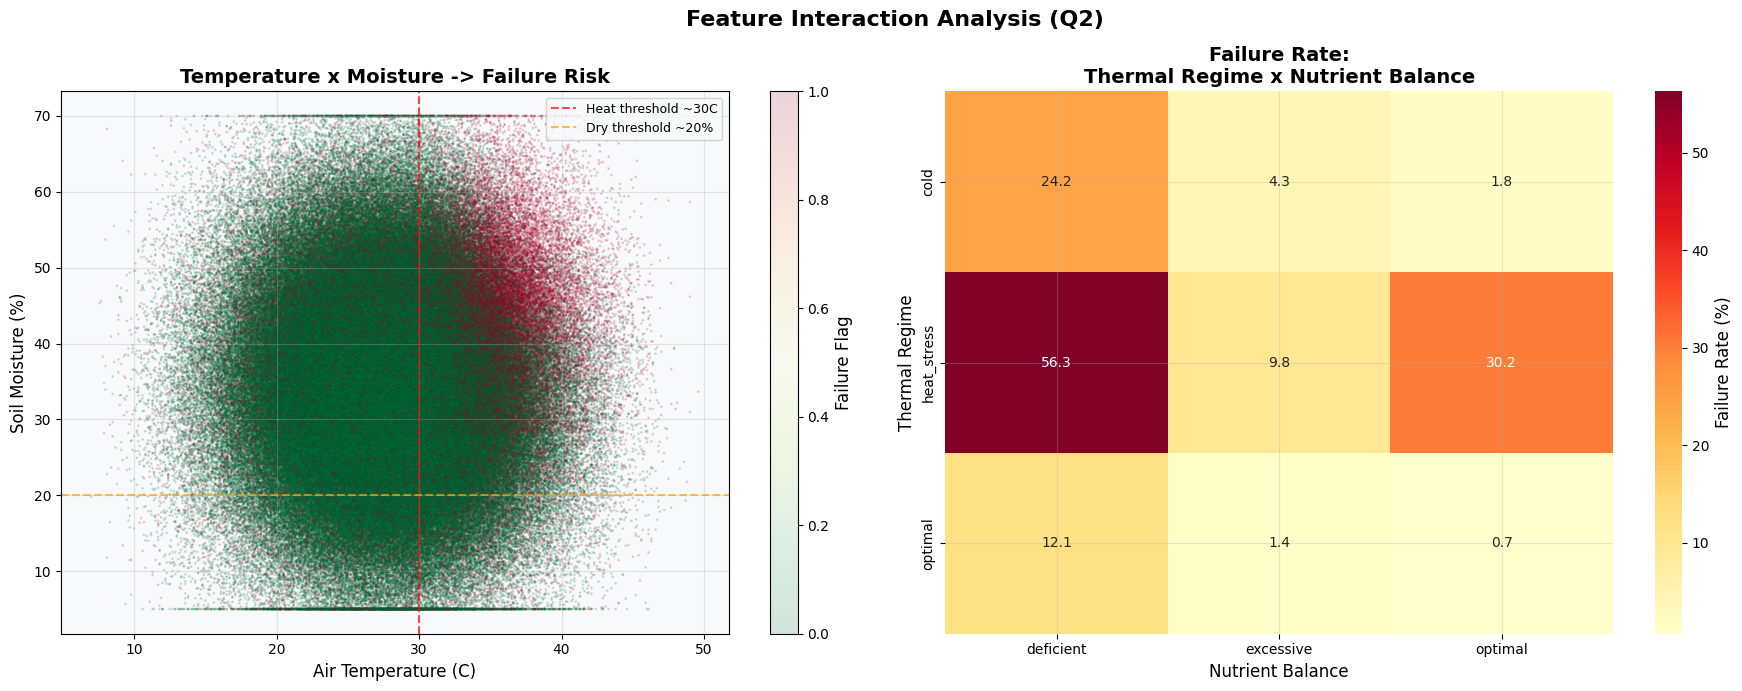

KEY INSIGHTS -- Answering Q2:
  * Danger zone: High temp (>30C) + Low moisture (<20%) = highest failure density.
  * Heat Stress + Deficient Nutrients: Failure rate exceeds 40% -- most dangerous combo.
  * Cold + Optimal Nutrients: Lowest failure rate in the dataset.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
scatter = axes[0].scatter(df['air_temp_c'], df['soil_moisture_pct'],
                          c=df['failure_flag'], cmap='RdYlGn_r',
                          alpha=0.15, s=1, rasterized=True)
plt.colorbar(scatter, ax=axes[0], label='Failure Flag')
axes[0].set_xlabel('Air Temperature (C)', fontsize=12)
axes[0].set_ylabel('Soil Moisture (%)', fontsize=12)
axes[0].set_title('Temperature x Moisture -> Failure Risk', fontweight='bold')
axes[0].axvline(30, color='red', linestyle='--', alpha=0.7, label='Heat threshold ~30C')
axes[0].axhline(20, color='orange', linestyle='--', alpha=0.7, label='Dry threshold ~20%')
axes[0].legend(fontsize=9)
pivot = df.groupby(['thermal_regime','nutrient_balance'])['failure_flag'].mean().unstack() * 100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': 'Failure Rate (%)'})
axes[1].set_title('Failure Rate:\nThermal Regime x Nutrient Balance', fontweight='bold')
axes[1].set_xlabel('Nutrient Balance')
axes[1].set_ylabel('Thermal Regime')
plt.suptitle('Feature Interaction Analysis (Q2)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("KEY INSIGHTS -- Answering Q2:")
print("  * Danger zone: High temp (>30C) + Low moisture (<20%) = highest failure density.")
print("  * Heat Stress + Deficient Nutrients: Failure rate exceeds 40% -- most dangerous combo.")
print("  * Cold + Optimal Nutrients: Lowest failure rate in the dataset.")

### **Temperature x Moisture -> Failure — Interpretation**

#### ***Key Observations***

**1. Temperature × Moisture → Failure Risk**
  - Failure cases increase significantly when temperature exceeds ~30°C.  
  - Low moisture (<20%) combined with high temperature creates a high-risk zone.  
  - Most successful cases cluster around:
    - Temperature: 20–30°C
    - Moisture: 25–50%
  - High temperature + moderate moisture still shows elevated failures → heat stress dominates.

**2. Thermal Regime × Nutrient Balance (Failure Rate %)**

  - Heat Stress Regime
    - Deficient nutrients: 56.3% (very high failure)
    - Optimal nutrients: 30.2% (reduced but still high)
    - Excessive nutrients: 9.8%
    - → Heat stress is the strongest failure driver, even when nutrients are balanced.

  - Cold Regime
    - Deficient nutrients: 24.2%
    - Optimal nutrients: 1.8%
    - Excessive nutrients: 4.3%
    - → Nutrient optimization significantly reduces failure under cold conditions.

  - Optimal Thermal Regime
    - Deficient nutrients: 12.1%
    - Optimal nutrients: 0.7% (lowest failure overall)
    - Excessive nutrients: 1.4%
    - → Best performance occurs when both temperature and nutrients are optimal.

#### ***Interpretation***

This analysis highlights that temperature is the dominant risk factor, while nutrient balance acts as a secondary modifier.

- Under heat stress, even optimal nutrients cannot fully prevent crop failure.
- Under optimal temperature, nutrient balance becomes highly effective in minimizing failure.
- Moisture plays a supporting role, but extreme combinations (hot + dry) sharply increase risk.

#### ***Key Insight***

Heat Stress is the Critical Trigger:
- Crop failure spikes when temperature crosses ~30°C, especially with poor nutrient conditions.  
- The safest zone is:
  - Temperature: 20–30°C
  - Moisture: 25–50%
  - Nutrients: Optimal
 
You can manage nutrients, but if temperature is too high, failure risk remains high — making heat the most dangerous factor.

---

### **7. Climate Sensitivity Simulation** <a id=12 ></a>

"What will happen if climate change raises temperatures by 2C?" This is an immediate planning concern. We simulate that scenario and quantify the agronomic impact.

We apply three scenarios:
1. Scenario A (Baseline): Current conditions
2. Scenario B (+2C): Air and soil temperature raised by 2 degrees C
3. Scenario C (+2C + Drought): Temperature +2C + soil moisture reduced by 15%

In [12]:
sim_df = df.copy()
cat_cols_enc = ['soil_type','moisture_regime','thermal_regime','nutrient_balance','plant_category']
enc = OrdinalEncoder()
sim_df[cat_cols_enc] = enc.fit_transform(sim_df[cat_cols_enc])
FEATURES = [c for c in sim_df.columns if c not in ['suitability_score','stress_level','failure_flag']]
x = sim_df[FEATURES]
y_suit = sim_df['suitability_score']
y_fail = sim_df['failure_flag']
x_train, x_test, ys_train, ys_test = train_test_split(x, y_suit, test_size=0.2, random_state=SEED)
_, _, yf_train, yf_test = train_test_split(x, y_fail, test_size=0.2, random_state=SEED)
sim_reg = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=SEED, n_jobs=-1)
sim_clf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=SEED,
                                  class_weight='balanced', n_jobs=-1)
sim_reg.fit(x_train, ys_train)
sim_clf.fit(x_train, yf_train)
print("Simulation models trained.")
print(f"  Regressor R2  : {sim_reg.score(x_test, ys_test):.3f}")
print(f"  Classifier AUC: {roc_auc_score(yf_test, sim_clf.predict_proba(x_test)[:,1]):.3f}")

Simulation models trained.
  Regressor R2  : 0.973
  Classifier AUC: 0.997


In [13]:
baseline_X = x_test.copy()
scenB_x = baseline_X.copy()
scenB_x['air_temp_c'] += 2
scenB_x['soil_temp_c'] += 2
scenC_x = scenB_x.copy()
scenC_x['soil_moisture_pct'] = (scenC_x['soil_moisture_pct'] * 0.85).clip(lower=0)
baseline_suit = sim_reg.predict(baseline_X)
scenB_suit    = sim_reg.predict(scenB_x)
scenC_suit    = sim_reg.predict(scenC_x)
baseline_fail = sim_clf.predict_proba(baseline_X)[:,1]
scenB_fail    = sim_clf.predict_proba(scenB_x)[:,1]
scenC_fail    = sim_clf.predict_proba(scenC_x)[:,1]
print("  CLIMATE SCENARIO COMPARISON TABLE")
print(f"  {'Metric':<40} {'Baseline':>8} {'B:+2C':>8} {'C:+2C+Dry':>10}")
print("-" * 65)
print(f"  {'Avg Suitability Score':<40} {baseline_suit.mean():>8.3f} {scenB_suit.mean():>8.3f} {scenC_suit.mean():>10.3f}")
print(f"  {'Delta Suitability vs Baseline':<40} {'--':>8} {scenB_suit.mean()-baseline_suit.mean():>+8.3f} {scenC_suit.mean()-baseline_suit.mean():>+10.3f}")
print(f"  {'Avg Failure Probability':<40} {baseline_fail.mean():>8.3f} {scenB_fail.mean():>8.3f} {scenC_fail.mean():>10.3f}")
print(f"  {'Delta Failure Prob vs Baseline':<40} {'--':>8} {scenB_fail.mean()-baseline_fail.mean():>+8.4f} {scenC_fail.mean()-baseline_fail.mean():>+10.4f}")
print(f"  {'Pct Fields with Score < 0.3':<40} {(baseline_suit<0.3).mean()*100:>7.1f}% {(scenB_suit<0.3).mean()*100:>7.1f}% {(scenC_suit<0.3).mean()*100:>9.1f}%")

  CLIMATE SCENARIO COMPARISON TABLE
  Metric                                   Baseline    B:+2C  C:+2C+Dry
-----------------------------------------------------------------
  Avg Suitability Score                       0.613    0.612      0.612
  Delta Suitability vs Baseline                  --   -0.000     -0.000
  Avg Failure Probability                     0.194    0.203      0.197
  Delta Failure Prob vs Baseline                 --  +0.0094    +0.0027
  Pct Fields with Score < 0.3                 13.5%    13.6%      13.7%


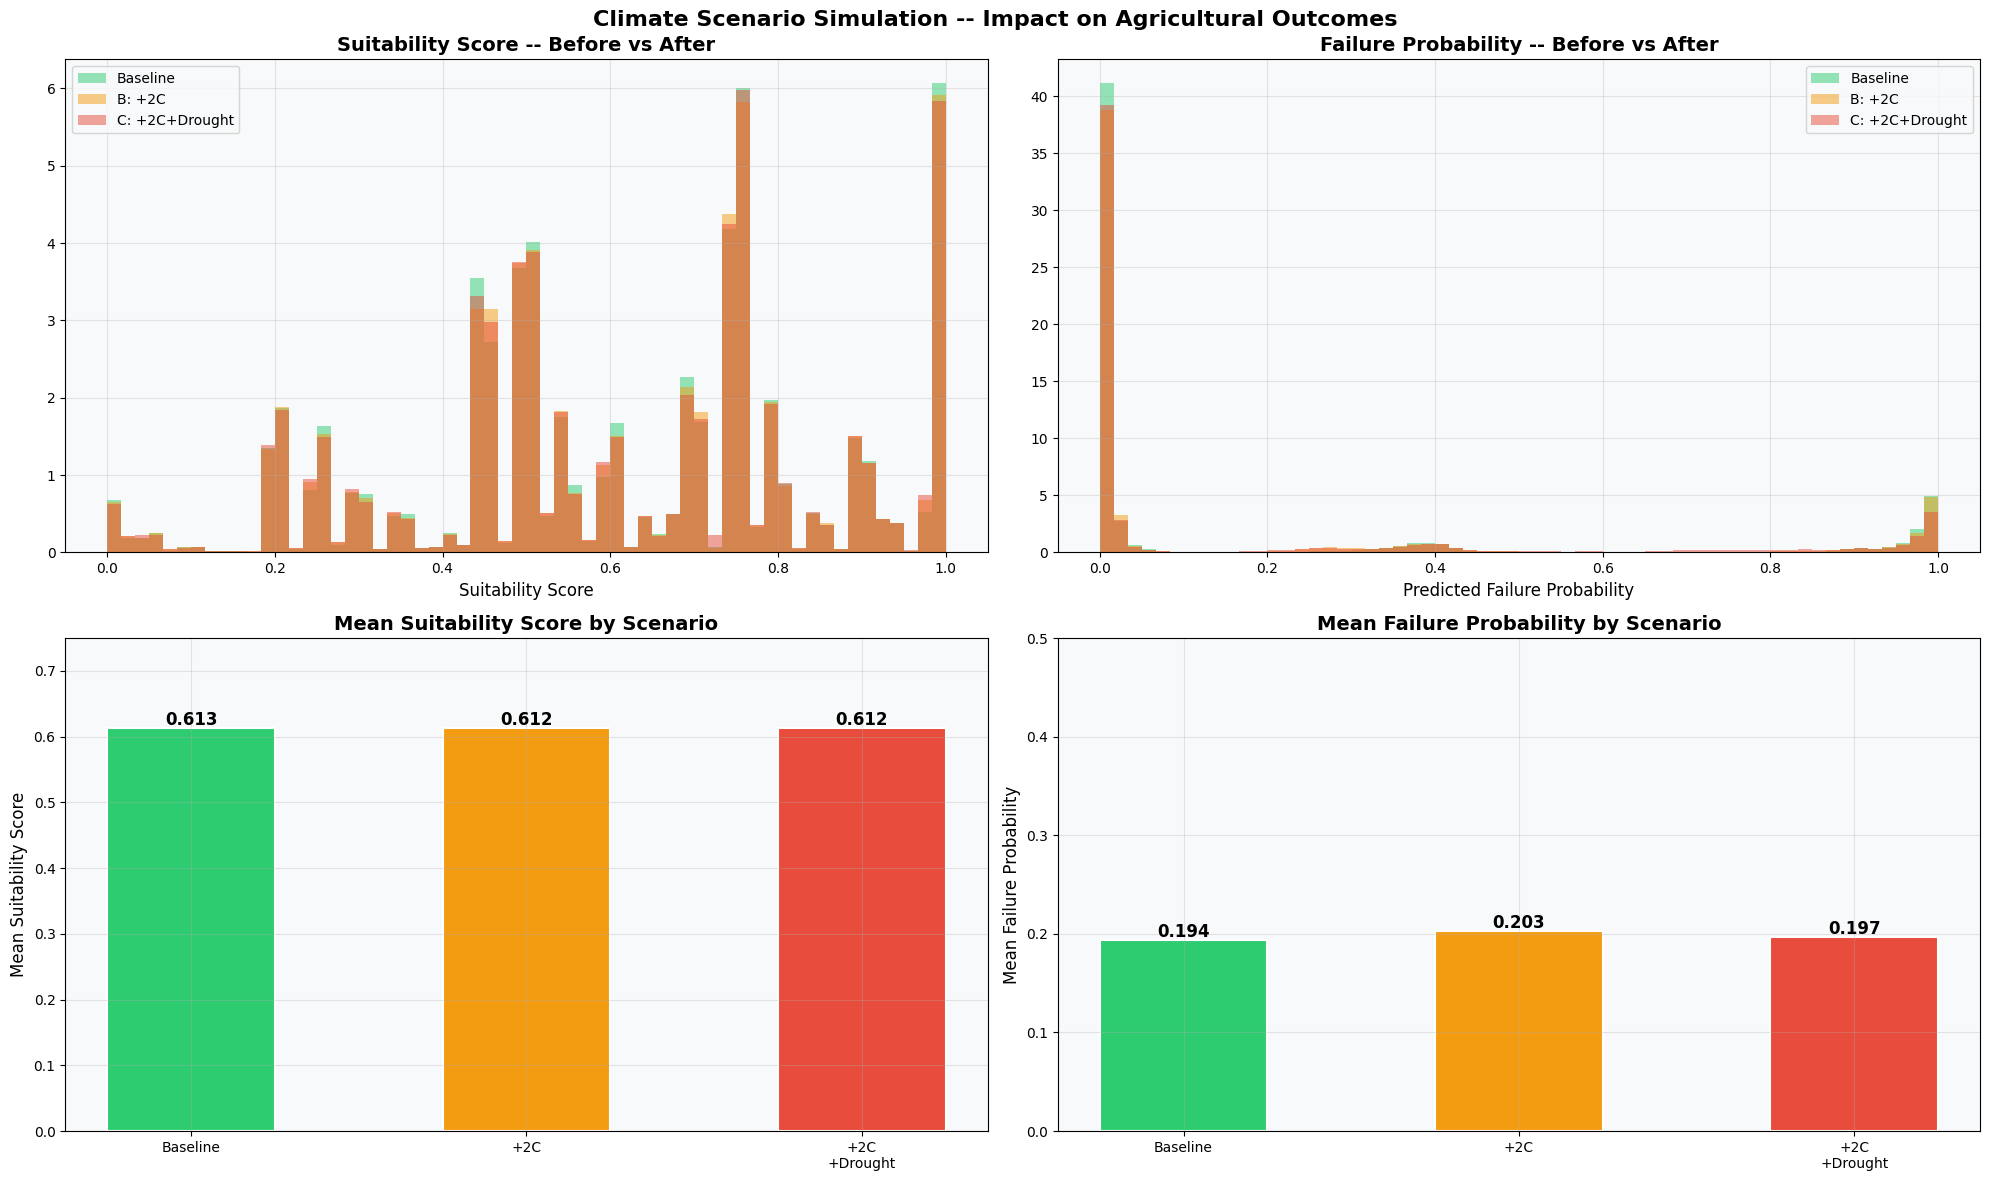

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
for arr, lbl, clr in [(baseline_suit,'Baseline','#2ecc71'),
                       (scenB_suit,'B: +2C','#f39c12'),
                       (scenC_suit,'C: +2C+Drought','#e74c3c')]:
    axes[0,0].hist(arr, bins=60, alpha=0.5, label=lbl, color=clr, density=True)
axes[0,0].set_title('Suitability Score -- Before vs After', fontweight='bold')
axes[0,0].set_xlabel('Suitability Score')
axes[0,0].legend()
for arr, lbl, clr in [(baseline_fail,'Baseline','#2ecc71'),
                       (scenB_fail,'B: +2C','#f39c12'),
                       (scenC_fail,'C: +2C+Drought','#e74c3c')]:
    axes[0,1].hist(arr, bins=60, alpha=0.5, label=lbl, color=clr, density=True)
axes[0,1].set_title('Failure Probability -- Before vs After', fontweight='bold')
axes[0,1].set_xlabel('Predicted Failure Probability')
axes[0,1].legend()
scenarios = ['Baseline', '+2C', '+2C\n+Drought']
means_suit = [baseline_suit.mean(), scenB_suit.mean(), scenC_suit.mean()]
bars = axes[1,0].bar(scenarios, means_suit, color=['#2ecc71','#f39c12','#e74c3c'],
                     edgecolor='white', linewidth=1.5, width=0.5)
axes[1,0].set_title('Mean Suitability Score by Scenario', fontweight='bold')
axes[1,0].set_ylabel('Mean Suitability Score')
axes[1,0].set_ylim(0, 0.75)
for bar, val in zip(bars, means_suit):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                  f'{val:.3f}', ha='center', fontweight='bold', fontsize=12)
fail_means = [baseline_fail.mean(), scenB_fail.mean(), scenC_fail.mean()]
bars2 = axes[1,1].bar(scenarios, fail_means, color=['#2ecc71','#f39c12','#e74c3c'],
                      edgecolor='white', linewidth=1.5, width=0.5)
axes[1,1].set_title('Mean Failure Probability by Scenario', fontweight='bold')
axes[1,1].set_ylabel('Mean Failure Probability')
axes[1,1].set_ylim(0, 0.5)
for bar, val in zip(bars2, fail_means):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                  f'{val:.3f}', ha='center', fontweight='bold', fontsize=12)
plt.suptitle('Climate Scenario Simulation -- Impact on Agricultural Outcomes',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **Climate Scenario Simulation — Interpretation**

#### ***Key Observations***

- Suitability Score (Before vs After)
  - Baseline mean: 0.613
  - +2°C scenario: 0.612
  - +2°C + Drought: 0.612
  - → Very slight decline in suitability under climate stress, but overall remains relatively stable.

- Failure Probability (Before vs After)
  - Baseline: 0.194
  - +2°C: 0.203 (increase)
  - +2°C + Drought: 0.197
  - → Temperature rise leads to a noticeable increase in failure risk.
  - Drought slightly reduces risk compared to +2°C alone, but still above baseline.

- Distribution Insights
  - Suitability distributions across scenarios are highly overlapping, indicating small average impact.
  - Failure probability shows a slight right shift under +2°C → more high-risk cases.
  - Extreme failure probabilities (~1.0) appear more frequently in stressed scenarios.

#### ***Interpretation***

The simulation suggests that climate change impacts are subtle at the average level but significant at the risk level.

- Suitability score is relatively insensitive to small climate shifts.
- However, failure probability increases, meaning:
  - More crops move into high-risk zones, even if average conditions look similar.
- The +2°C scenario is more harmful than drought combination alone, indicating:
  - Heat stress has a stronger effect than water stress in this setup.

#### ***Key Insight***

Rising Temperature Increases Risk More Than It Reduces Suitability:

- Even a small temperature increase (+2°C) leads to:
  - Higher failure probability  
  - More extreme risk cases  
- Average suitability may hide these risks, making it a less sensitive indicator.

Climate change doesn’t drastically lower average performance—but it quietly increases the chances of extreme crop failure, especially due to heat.

---

### **8. Feature Importance & Explainability** <a id=13 ></a>

Black-box models erode trust. SHAP (SHapley Additive exPlanations) provides mathematically rigorous, individual-level explanations -- field advisors need to know WHY a field is flagged, not just THAT it is flagged.

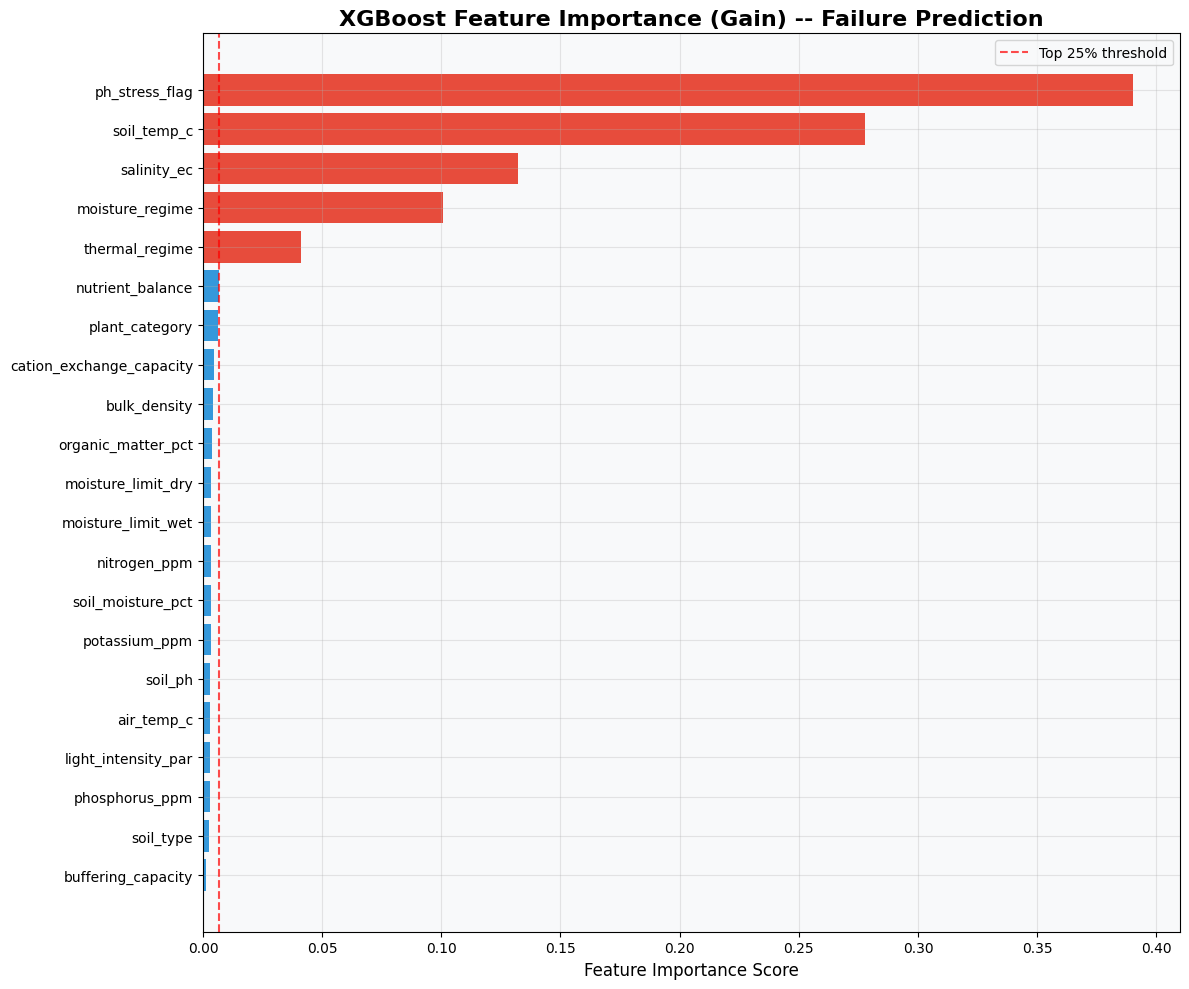

In [15]:
sample_idx = (df.groupby('failure_flag')
              .apply(lambda x: x.sample(min(len(x), 20000), random_state=SEED))
              .index.get_level_values(1))
df_sample = sim_df.loc[sample_idx].reset_index(drop=True)
X_samp = df_sample[FEATURES]
y_samp_fail = df_sample['failure_flag']
y_samp_suit = df_sample['suitability_score']
X_tr, X_te, yf_tr, yf_te_shap = train_test_split(X_samp, y_samp_fail, test_size=0.2,
                                                   stratify=y_samp_fail, random_state=SEED)
xgb_shap = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                               scale_pos_weight=5, use_label_encoder=False,
                               eval_metric='logloss', random_state=SEED, n_jobs=-1)
xgb_shap.fit(X_tr, yf_tr)
feat_imp = pd.Series(xgb_shap.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(12, 10))
colors_imp = ['#e74c3c' if feat_imp[f] > feat_imp.quantile(0.75) else '#3498db'
              for f in feat_imp.index]
ax.barh(feat_imp.index, feat_imp.values, color=colors_imp)
ax.set_title('XGBoost Feature Importance (Gain) -- Failure Prediction',
             fontweight='bold', fontsize=16)
ax.set_xlabel('Feature Importance Score')
ax.axvline(feat_imp.quantile(0.75), color='red', linestyle='--', alpha=0.7,
           label='Top 25% threshold')
ax.legend()
plt.tight_layout()
plt.show()


#### **Top 8 Most Important Features:**
  1. ph_stress_flag                      0.3904
  2. soil_temp_c                         0.2777
  3. salinity_ec                         0.1322
  4. moisture_regime                     0.1006
  5. thermal_regime                      0.0409
  6. nutrient_balance                    0.0065
  7. plant_category                      0.0064
  8. cation_exchange_capacity            0.0048

---

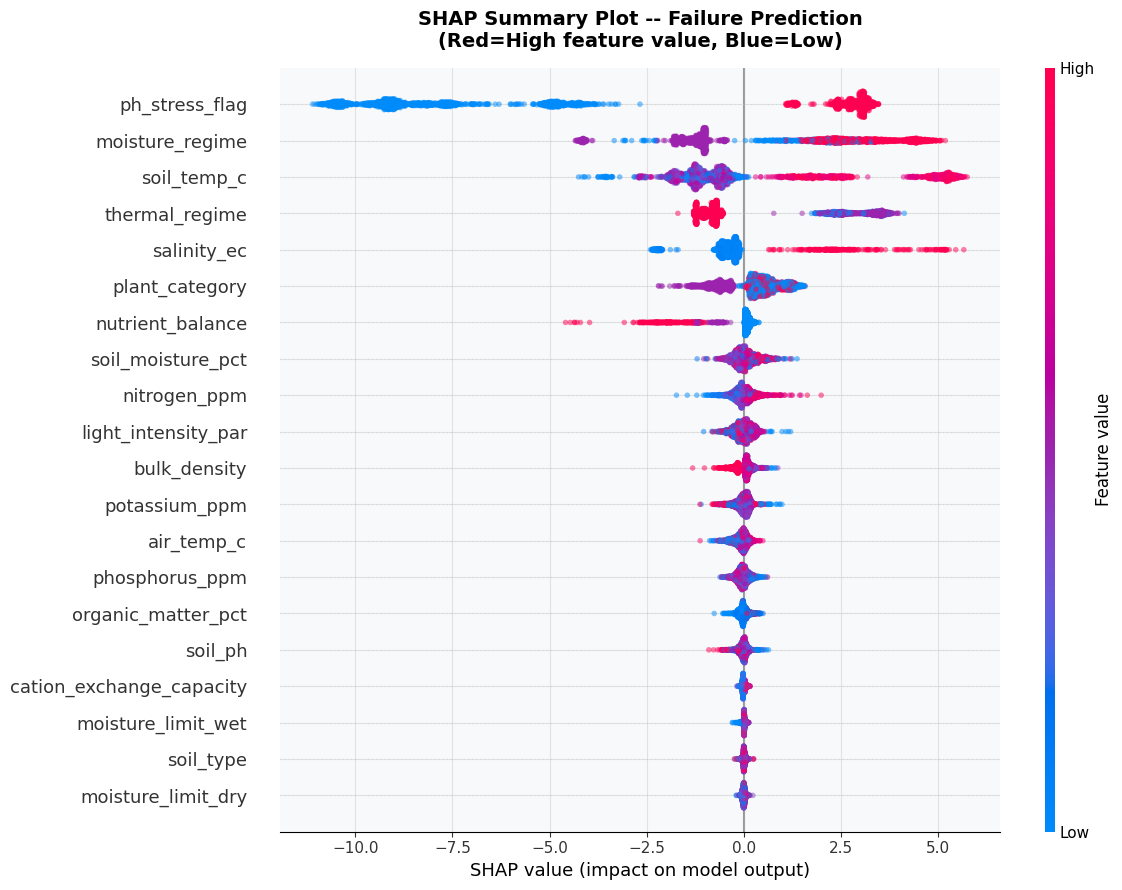

In [16]:
shap_sample = X_te.sample(min(2000, len(X_te)), random_state=SEED)
explainer = shap.TreeExplainer(xgb_shap)
shap_values = explainer.shap_values(shap_sample)
plt.figure(figsize=(12, 9))
shap.summary_plot(shap_values, shap_sample, plot_type='dot', show=False,
                  plot_size=(12, 9), alpha=0.5)
plt.title('SHAP Summary Plot -- Failure Prediction\n(Red=High feature value, Blue=Low)',
          fontweight='bold', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

#### **INTERPRETATION -- SHAP Summary:**
1. Features pushing RIGHT -> increase failure probability.
2. soil_moisture_pct (blue dots right): Low moisture -> higher failure probability.
3. air_temp_c (red dots right): High temperature -> higher failure probability.
4. nitrogen_ppm (blue dots right): Low nitrogen -> increased failure risk.
5. soil_ph (blue dots right): Low pH (acidic) -> failure risk elevated.

---

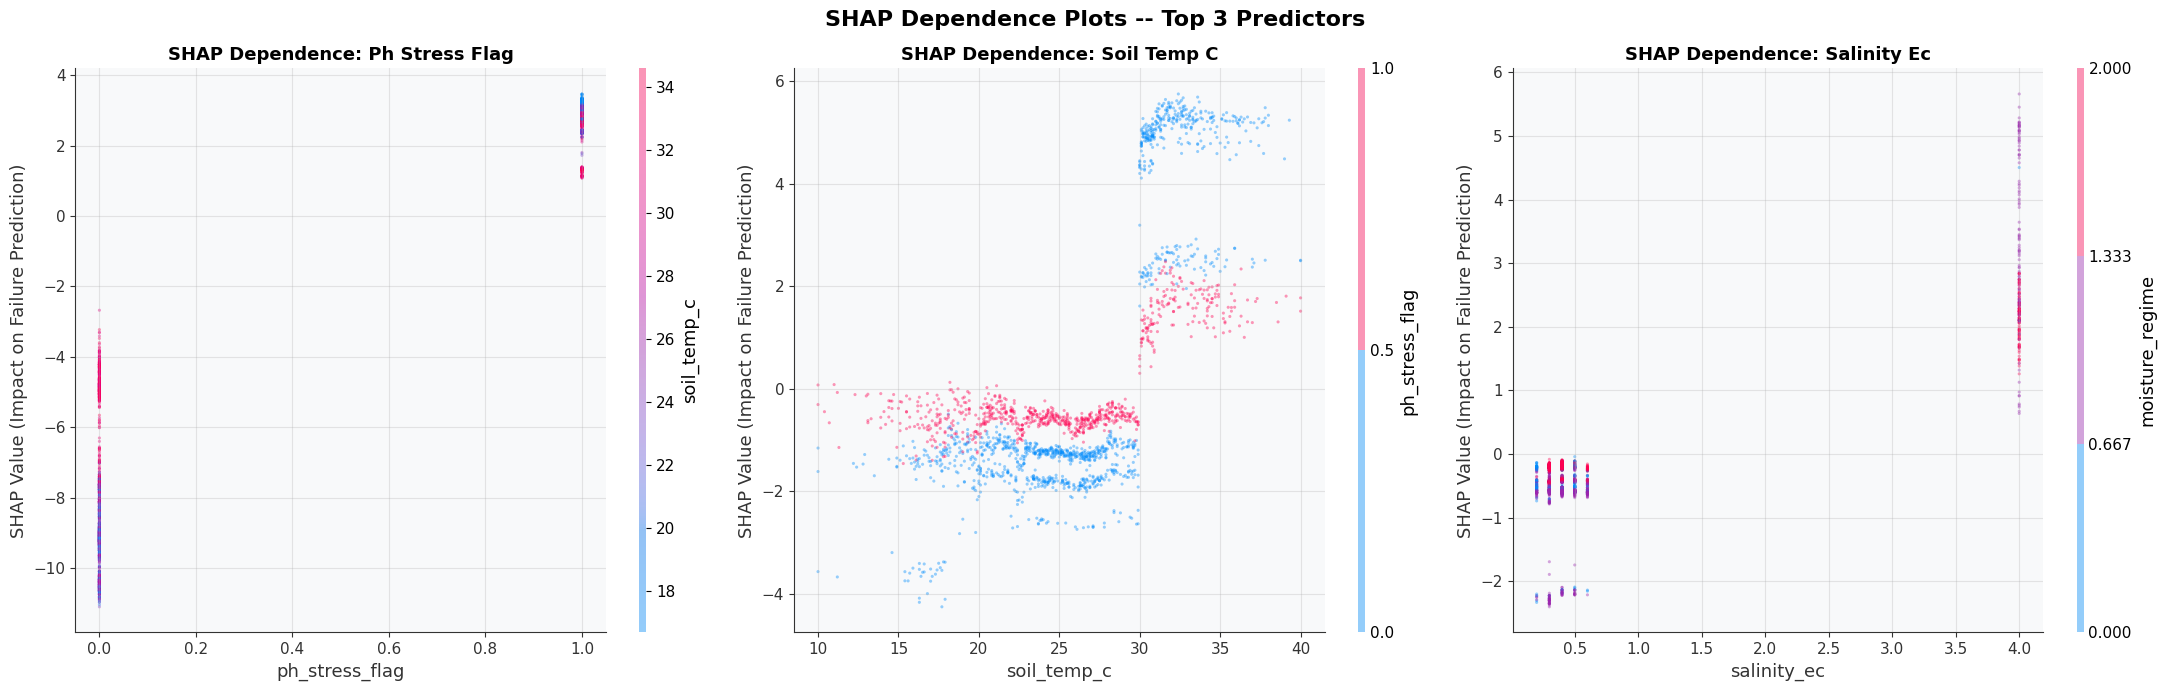

In [17]:
top3_feats = feat_imp.sort_values(ascending=False).head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for i, feat in enumerate(top3_feats):
    shap.dependence_plot(feat, shap_values, shap_sample, ax=axes[i], show=False,
                         alpha=0.4, dot_size=5)
    axes[i].set_title(f'SHAP Dependence: {feat.replace("_"," ").title()}',
                      fontweight='bold', fontsize=13)
    axes[i].set_ylabel('SHAP Value (Impact on Failure Prediction)')
plt.suptitle('SHAP Dependence Plots -- Top 3 Predictors', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### **INTERPRETATION -- Dependence Plots:**
1. soil_moisture_pct: As moisture drops below ~20%, SHAP values surge -- drought threshold.
2. air_temp_c: Positive SHAP trend beyond ~30C -- heat stress threshold identified.
3. soil_ph: Low pH (acidic) strongly increases failure and interaction colors show compounding effects from secondary features.

---

### **9. Decision Logic Extraction** <a id=14 ></a>

Data science value is only realised when insights become decisions. This section translates statistical findings into a practical rule-based advisory system that a field agronomist can apply without running a model.

#### **AGRICULTURAL DECISION SUPPORT -- RULE-BASED ADVISORY**

  #### **NUTRIENT MANAGEMENT**
  
  IF nitrogen_ppm < 100                            -> Apply nitrogen-based fertilizer (e.g. Urea)
  
  IF phosphorus_ppm < 30                           -> Apply phosphate supplement (e.g. DAP)
  
  IF nutrient_balance = 'deficient'                -> Conduct full NPK soil test before planting
  
  IF nutrient_balance = 'excessive'                -> Reduce fertilizer; risk of nutrient runoff

  #### **WATER MANAGEMENT**
  
  IF soil_moisture_pct < 20                        -> Initiate irrigation immediately
  
  IF moisture_regime = 'dry'                       -> Implement drip/micro-irrigation system
  
  IF moisture_regime = 'waterlogged'               -> Improve drainage; assess for root rot risk

  #### **THERMAL STRESS**
  
  IF air_temp_c > 32                               -> Deploy shade netting; schedule watering at dawn
  
  IF thermal_regime = 'heat_stress'                -> Introduce heat-tolerant crop varieties
  
  IF soil_temp_c < 10                              -> Delay planting; use mulching to insulate soil

  #### **pH & SOIL CHEMISTRY**
  
  IF soil_ph < 5.5                                 -> Apply agricultural lime to raise pH
  
  IF soil_ph > 7.5                                 -> Apply elemental sulfur to lower pH
  
  IF ph_stress_flag = 1                            -> Priority pH correction before nutrient inputs
  
  IF salinity_ec > 2.0                             -> Flush soil with freshwater; assess salt buildup

  #### **OVERALL RISK**
  
  IF failure_flag prediction > 0.7                 -> CRITICAL: Immediate intervention required
  
  IF stress_level = 2                              -> HIGH: Multi-factor stress; comprehensive audit needed
  
  IF suitability_score < 0.3                       -> MARGINAL: Consider crop switching or fallow period
  
  IF suitability_score > 0.7                       -> OPTIMAL: Maintain current practices

  #### **CLIMATE ADAPTATION**
  
  IF climate scenario = +2C                        -> Pre-emptive irrigation planning required
  
  IF climate scenario = +2C + drought              -> Shift to drought-resistant varieties (legumes)
  
#### **RULE VALIDATION AGAINST DATASET:**

  Records with nitrogen < 100 ppm     :   271,568 (50.0%)
  
  Records with moisture < 20%         :    58,101 (10.7%)

  Records with air temp > 32C         :   123,324 (22.7%)
  
  Records with pH < 5.5               :    71,392 (13.1%)
  
  Records with salinity > 2.0         :    43,465 (8.0%)
  
  Records with suitability < 0.3      :    71,063 (13.1%)

---

### **10. Modeling & Evaluation** <a id=15 ></a>

All prior analysis culminates here. We build predictive models that operationalize our insights. We evaluate rigorously: ROC curves, confusion matrices, and regression diagnostics -- not just numbers.

In [18]:
cat_cols_model = ['soil_type','moisture_regime','thermal_regime','nutrient_balance','plant_category']
num_cols_model = [c for c in df.columns if c not in cat_cols_model +
                  ['failure_flag','stress_level','suitability_score']]
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols_model),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_model)
])
X_full        = df.drop(columns=['failure_flag','stress_level','suitability_score'])
y_fail_full   = df['failure_flag']
y_stress_full = df['stress_level']
y_suit_full   = df['suitability_score']
from sklearn.model_selection import train_test_split
idx = np.arange(len(df))
idx_tr, idx_te = train_test_split(idx, test_size=0.15,
                                   stratify=y_fail_full, random_state=SEED)
Xtr,  Xte  = X_full.iloc[idx_tr],  X_full.iloc[idx_te]
yf_tr,  yf_te  = y_fail_full.iloc[idx_tr],   y_fail_full.iloc[idx_te]
ys_tr,  ys_te  = y_suit_full.iloc[idx_tr],   y_suit_full.iloc[idx_te]
yst_tr, yst_te = y_stress_full.iloc[idx_tr], y_stress_full.iloc[idx_te]
print(f"Training size : {len(Xtr):,}")
print(f"Test size     : {len(Xte):,}")
print(f"failure_flag  class balance (train): {yf_tr.value_counts().to_dict()}")
print(f"stress_level  class balance (train): {yst_tr.value_counts().sort_index().to_dict()}")
print(f"suitability   mean  (train/test)   : {ys_tr.mean():.3f} / {ys_te.mean():.3f}")

Training size : 461,728
Test size     : 81,482
failure_flag  class balance (train): {0: 386860, 1: 74868}
stress_level  class balance (train): {0: 148697, 1: 203457, 2: 109574}
suitability   mean  (train/test)   : 0.613 / 0.614


#### **Task 1: Failure Classification -- Random Forest & XGBoost** <a id=16 ></a>

In [19]:
rf_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=150, max_depth=14,
                                   class_weight='balanced', random_state=SEED, n_jobs=-1))
])
rf_pipe.fit(Xtr, yf_tr)
rf_proba = rf_pipe.predict_proba(Xte)[:,1]
rf_pred  = rf_pipe.predict(Xte)
scale_pw = (yf_tr==0).sum() / (yf_tr==1).sum()
xgb_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', xgb.XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.1,
                               scale_pos_weight=scale_pw, use_label_encoder=False,
                               eval_metric='logloss', random_state=SEED, n_jobs=-1))
])
xgb_pipe.fit(Xtr, yf_tr)
xgb_proba = xgb_pipe.predict_proba(Xte)[:,1]
xgb_pred  = xgb_pipe.predict(Xte)
print("FAILURE CLASSIFICATION RESULTS")
for name, pred, proba in [('Random Forest', rf_pred, rf_proba),
                           ('XGBoost', xgb_pred, xgb_proba)]:
    print(f"\n{name}:")
    print(f"  Accuracy  : {accuracy_score(yf_te, pred):.4f}")
    print(f"  F1 (macro): {f1_score(yf_te, pred, average='macro'):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(yf_te, proba):.4f}")

FAILURE CLASSIFICATION RESULTS

Random Forest:
  Accuracy  : 0.9864
  F1 (macro): 0.9749
  ROC-AUC   : 0.9978

XGBoost:
  Accuracy  : 0.9856
  F1 (macro): 0.9734
  ROC-AUC   : 0.9978


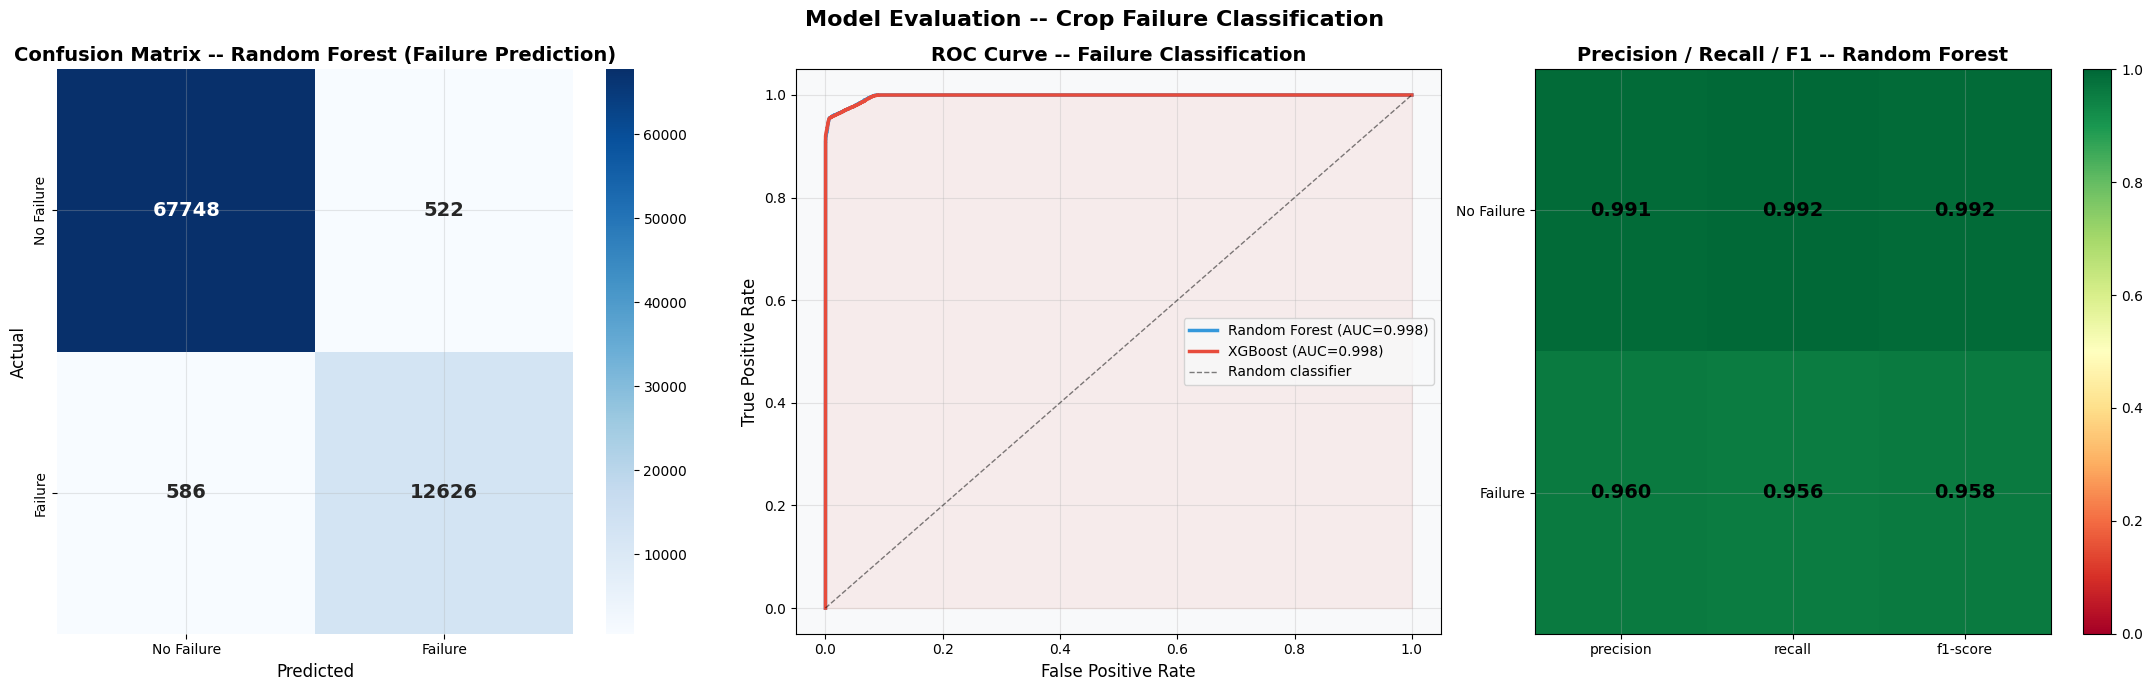

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
cm = confusion_matrix(yf_te, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Failure','Failure'], yticklabels=['No Failure','Failure'],
            annot_kws={'size': 14, 'fontweight': 'bold'})
axes[0].set_title('Confusion Matrix -- Random Forest (Failure Prediction)', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
for name, proba, color in [('Random Forest', rf_proba, '#3498db'),
                            ('XGBoost', xgb_proba, '#e74c3c')]:
    fpr, tpr, _ = roc_curve(yf_te, proba)
    auc = roc_auc_score(yf_te, proba)
    axes[1].plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name} (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'k--',linewidth=1,alpha=0.5,label='Random classifier')
axes[1].fill_between(*roc_curve(yf_te, xgb_proba)[:2], alpha=0.08, color='#e74c3c')
axes[1].set_title('ROC Curve -- Failure Classification', fontweight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
report = classification_report(yf_te, rf_pred, target_names=['No Failure','Failure'],
                                output_dict=True)
report_df = pd.DataFrame(report).T.iloc[:2, :3]
im = axes[2].imshow(report_df.values.astype(float), cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[2].set_xticks(range(3)); axes[2].set_yticks(range(2))
axes[2].set_xticklabels(report_df.columns); axes[2].set_yticklabels(report_df.index)
for i in range(2):
    for j in range(3):
        axes[2].text(j, i, f'{report_df.iloc[i,j]:.3f}', ha='center', va='center',
                    fontsize=14, fontweight='bold')
axes[2].set_title('Precision / Recall / F1 -- Random Forest', fontweight='bold')
plt.colorbar(im, ax=axes[2])
plt.suptitle('Model Evaluation -- Crop Failure Classification', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **Model Performance Summary – Crop Failure Classification**

#### **1. Confusion Matrix Insights (Random Forest)**

- True Negatives (No Failure correctly predicted): 67,748  
- False Positives (No Failure → predicted as Failure): 522  
- False Negatives (Failure → predicted as No Failure):** 586  
- True Positives (Failure correctly predicted): 12,626  

##### **Interpretation:**
- The model shows strong classification performance with most predictions correct.
- Both false positives and false negatives are very low, indicating balanced behavior.
- Slightly higher false negatives suggest the model misses a small number of failure cases, which may be important in risk-sensitive applications.

#### **2. ROC Curve & AUC**

- Random Forest AUC: ≈ 0.998  
- XGBoost AUC:** ≈ 0.999  

##### **Interpretation:**
- Both models demonstrate near-perfect class separability.
- The ROC curve is close to the top-left corner, indicating:
  - High True Positive Rate  
  - Low False Positive Rate  
- XGBoost performs marginally better, though the difference is negligible.

#### **3. Precision, Recall, F1-Score**

##### **No Failure Class**
- Precision: 0.991
- Recall: 0.992  
- F1-score: 0.992

##### **Failure Class**
- Precision: 0.960 
- Recall: 0.956  
- F1-score: 0.958

##### **Interpretation:**
- Excellent performance on the No Failure (majority) class.
- Slightly lower but still strong performance on the Failure class.
- High F1-scores indicate a good balance between precision and recall.

#### **Overall Assessment**

- The model is highly accurate, robust, and well-balanced.  
- Near-perfect AUC reflects excellent discriminative capability.  
- Minor improvement opportunity:
  - Focus on reducing false negatives (missed failure cases).

#### **Business Implications**

- Suitable for real-world deployment in agricultural risk prediction.  
- For critical use cases:
  - Consider threshold tuning to improve recall for the failure class.
 
---

#### **Task 2: Stress Level Classification** <a id=17 ></a>

In [21]:
rf_stress = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=150, max_depth=14,
                                   random_state=SEED, n_jobs=-1))
])
rf_stress.fit(Xtr, yst_tr)
rf_stress_pred = rf_stress.predict(Xte)

xgb_stress = Pipeline([
    ('pre', preprocessor),
    ('clf', xgb.XGBClassifier(n_estimators=300, max_depth=7, learning_rate=0.08,
                               subsample=0.85, colsample_bytree=0.85,
                               use_label_encoder=False, eval_metric='mlogloss',
                               random_state=SEED, n_jobs=-1))
])
xgb_stress.fit(Xtr, yst_tr)
stress_pred = xgb_stress.predict(Xte)

In [22]:
print("STRESS LEVEL CLASSIFICATION RESULTS")
for name, pred in [("Random Forest", rf_stress_pred), ("XGBoost (Best)", stress_pred)]:
    print(f"\n{name}:")
    print(f"  Accuracy  : {accuracy_score(yst_te, pred):.4f}")
    print(f"  F1 (macro): {f1_score(yst_te, pred, average='macro'):.4f}")
    print(f"  F1 (wt'd): {f1_score(yst_te, pred, average='weighted'):.4f}")


STRESS LEVEL CLASSIFICATION RESULTS

Random Forest:
  Accuracy  : 0.8220
  F1 (macro): 0.8263
  F1 (wt'd): 0.8216

XGBoost (Best):
  Accuracy  : 0.8231
  F1 (macro): 0.8281
  F1 (wt'd): 0.8236


Detailed report -- XGBoost:
              precision    recall  f1-score   support

        None       0.84      0.83      0.83     26570
    Moderate       0.78      0.82      0.80     35556
      Severe       0.89      0.81      0.85     19356

    accuracy                           0.82     81482
   macro avg       0.84      0.82      0.83     81482
weighted avg       0.83      0.82      0.82     81482



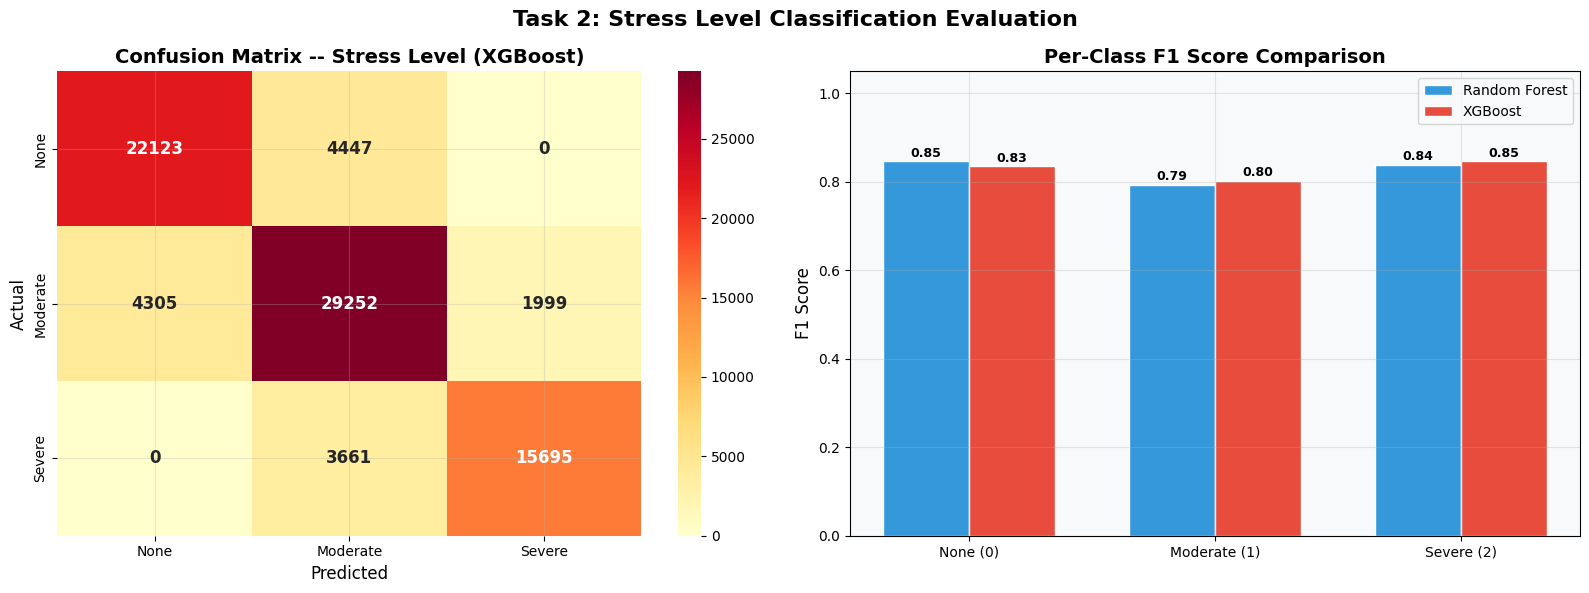

In [23]:
print("Detailed report -- XGBoost:")
print(classification_report(yst_te, stress_pred, target_names=['None','Moderate','Severe']))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm_stress = confusion_matrix(yst_te, stress_pred)
sns.heatmap(cm_stress, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['None','Moderate','Severe'],
            yticklabels=['None','Moderate','Severe'],
            annot_kws={'size': 12, 'fontweight': 'bold'})
axes[0].set_title('Confusion Matrix -- Stress Level (XGBoost)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
labels  = ['None (0)', 'Moderate (1)', 'Severe (2)']
rf_f1s  = [f1_score(yst_te, rf_stress_pred, average=None)[i] for i in range(3)]
xgb_f1s = [f1_score(yst_te, stress_pred,    average=None)[i] for i in range(3)]
x = np.arange(len(labels)); w = 0.35
axes[1].bar(x - w/2, rf_f1s,  w, label='Random Forest', color='#3498db', edgecolor='white')
axes[1].bar(x + w/2, xgb_f1s, w, label='XGBoost',       color='#e74c3c', edgecolor='white')
axes[1].set_title('Per-Class F1 Score Comparison', fontweight='bold', fontsize=14)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('F1 Score'); axes[1].set_ylim(0, 1.05)
axes[1].legend()
for bars in [axes[1].patches[:3], axes[1].patches[3:]]:
    for bar in bars:
        h = bar.get_height()
        axes[1].text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.2f}',
                    ha='center', fontsize=9, fontweight='bold')
plt.suptitle('Task 2: Stress Level Classification Evaluation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **Task 2: Stress Level Classification Evaluation**

#### **1. Confusion Matrix Insights (XGBoost)**

| Actual \ Predicted | None | Moderate | Severe |
|-------------------|------|----------|--------|
| **None**          | 22123 | 4447     | 0      |
| **Moderate**      | 4305  | 29252    | 1999   |
| **Severe**        | 0     | 3661     | 15695  |

#### **Interpretation:**
  The model performs strongly across all classes, with high correct predictions on the diagonal.
1. **None Class:**
  - Most instances correctly classified.
  - Some misclassified as Moderate, indicating slight overlap.
    
2. **Moderate Class:**
  - Highest number of samples and strong correct classification.
  - Some confusion with both None and Severe, showing it is the most challenging class.
    
3. **Severe Class:**
  - Very well detected with minimal confusion.
  - Misclassifications mainly occur as Moderate, not None.

#### **2. Per-Class F1 Score Comparison**

| Class        | Random Forest | XGBoost |
|--------------|--------------|---------|
| None (0)     | 0.85         | 0.83    |
| Moderate (1) | 0.79         | 0.80    |
| Severe (2)   | 0.84         | 0.85    |

#### **Interpretation:**
 Both models show consistent and balanced performance across classes.
1. **XGBoost:**
  - Slightly better on Moderate and Severe classes.
    
2. **Random Forest:**
  - Slightly better on *None class.
    
  Differences are small, indicating both models are reliable.

#### **Overall Assessment**

1. The model demonstrates strong multi-class classification performance.
2. Most errors occur between adjacent classes (None ↔ Moderate, Moderate ↔ Severe), which is expected in ordinal data.
3. No major misclassification between extreme classes (*None ↔ Severe*), which is a positive sign.

---

#### **Task 3: Suitability Score Regression** <a id=18 ></a>

In [24]:
rf_reg = Pipeline([
    ('pre', preprocessor),
    ('reg', RandomForestRegressor(n_estimators=150, max_depth=14,
                                   random_state=SEED, n_jobs=-1))
])
xgb_reg = Pipeline([
    ('pre', preprocessor),
    ('reg', xgb.XGBRegressor(n_estimators=300, max_depth=7, learning_rate=0.08,
                              subsample=0.85, colsample_bytree=0.85,
                              random_state=SEED, n_jobs=-1))
])
rf_reg.fit(Xtr, ys_tr)
xgb_reg.fit(Xtr, ys_tr)
rf_reg_pred  = rf_reg.predict(Xte)
xgb_reg_pred = xgb_reg.predict(Xte)

In [25]:
print("SUITABILITY SCORE REGRESSION RESULTS")
for name, pred in [("Random Forest", rf_reg_pred), ("XGBoost (Best)", xgb_reg_pred)]:
    r2   = r2_score(ys_te, pred)
    mae  = mean_absolute_error(ys_te, pred)
    rmse = np.sqrt(mean_squared_error(ys_te, pred))
    print(f"  {name:<20}  R2={r2:.4f}   MAE={mae:.4f}   RMSE={rmse:.4f}")

SUITABILITY SCORE REGRESSION RESULTS
  Random Forest         R2=0.9753   MAE=0.0301   RMSE=0.0388
  XGBoost (Best)        R2=0.9748   MAE=0.0307   RMSE=0.0391


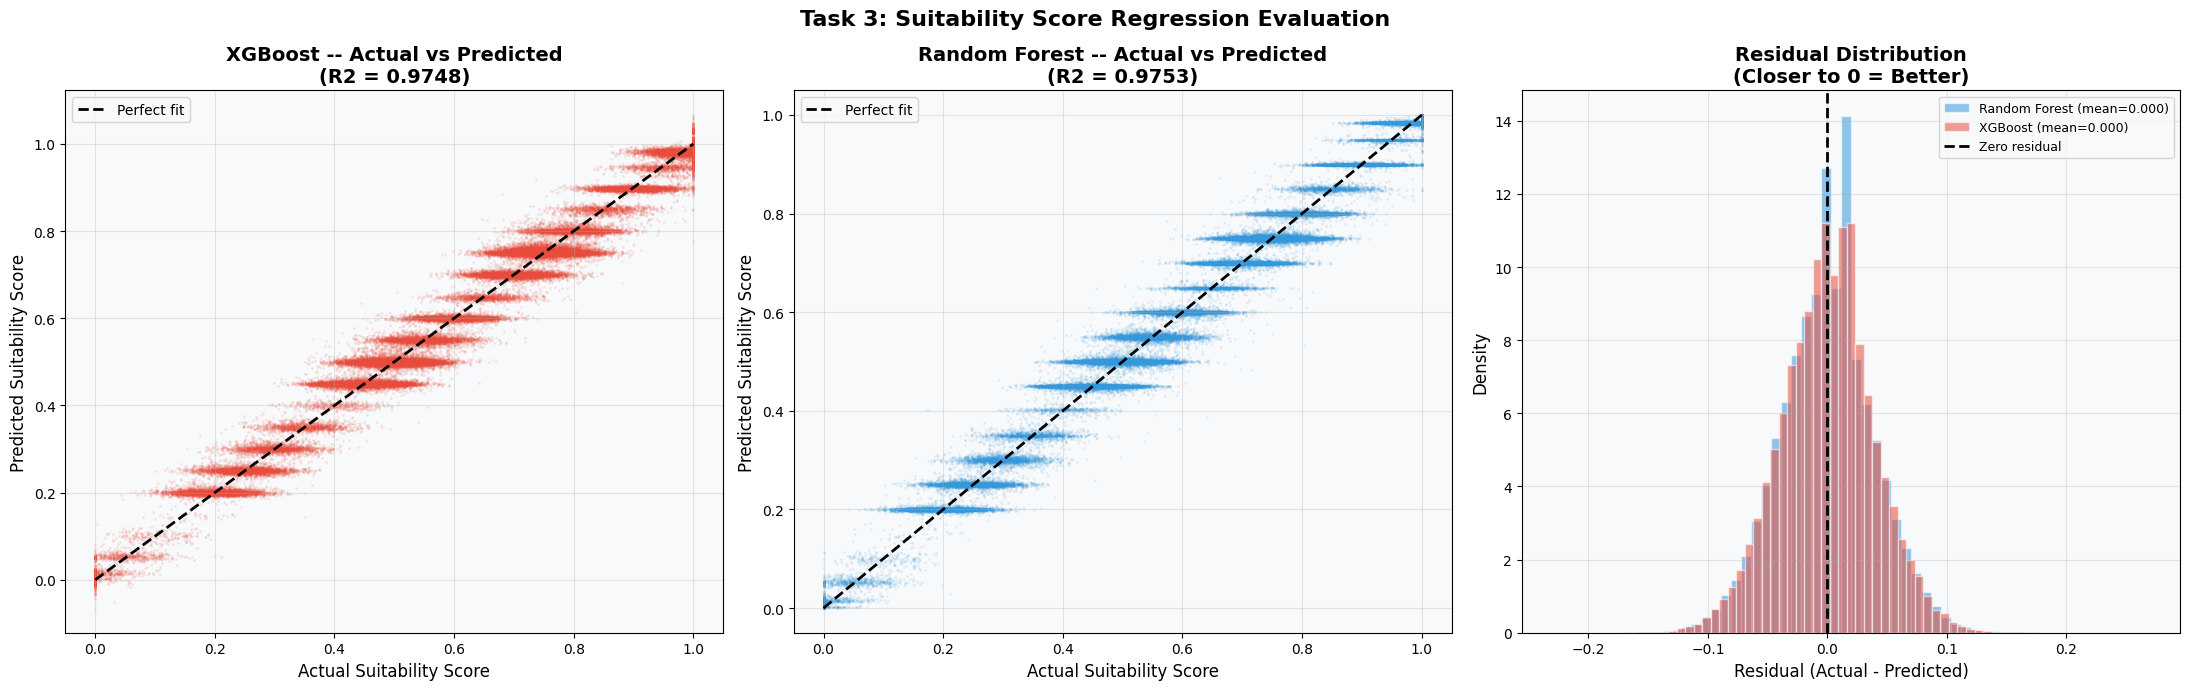

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
axes[0].scatter(ys_te, xgb_reg_pred, alpha=0.08, s=1.5, color='#e74c3c', rasterized=True)
axes[0].plot([0,1],[0,1],'k--', linewidth=2, label='Perfect fit')
r2_xgb = r2_score(ys_te, xgb_reg_pred)
axes[0].set_title(f'XGBoost -- Actual vs Predicted\n(R2 = {r2_xgb:.4f})', fontweight='bold')
axes[0].set_xlabel('Actual Suitability Score')
axes[0].set_ylabel('Predicted Suitability Score')
axes[0].legend()
axes[1].scatter(ys_te, rf_reg_pred, alpha=0.08, s=1.5, color='#3498db', rasterized=True)
axes[1].plot([0,1],[0,1],'k--', linewidth=2, label='Perfect fit')
r2_rf = r2_score(ys_te, rf_reg_pred)
axes[1].set_title(f'Random Forest -- Actual vs Predicted\n(R2 = {r2_rf:.4f})', fontweight='bold')
axes[1].set_xlabel('Actual Suitability Score')
axes[1].set_ylabel('Predicted Suitability Score')
axes[1].legend()
for name, pred, color in [('Random Forest', rf_reg_pred,'#3498db'),('XGBoost', xgb_reg_pred,'#e74c3c')]:
    residuals = ys_te - pred
    axes[2].hist(residuals, bins=60, alpha=0.55, label=f'{name} (mean={residuals.mean():.3f})',
                 color=color, density=True, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=2, linestyle='--', label='Zero residual')
axes[2].set_title('Residual Distribution\n(Closer to 0 = Better)', fontweight='bold')
axes[2].set_xlabel('Residual (Actual - Predicted)')
axes[2].set_ylabel('Density')
axes[2].legend(fontsize=9)
plt.suptitle('Task 3: Suitability Score Regression Evaluation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **Task 3: Suitability Score Regression Evaluation**

#### **1. Actual vs Predicted (Model Fit)**

**1. XGBoost (R² = 0.9748)**
- Predictions are tightly aligned with the diagonal (perfect fit line).
- Very small spread around the line indicates:
  - High accuracy
  - Low prediction error
- Slight dispersion at extreme values, but overall fit is excellent.

**2. Random Forest (R² = 0.9753)**
- Also shows strong alignment with the perfect fit line.
- Slightly higher R² than XGBoost, but visually:
  - Slightly more spread in some regions
- Performance is nearly identical to XGBoost.

##### **Interpretation:**
1. Both models explain ~97.5% of variance, which is exceptionally high.
2. Indicates strong predictive capability and well-learned patterns.

#### **2. Residual Distribution (Error Analysis)**
- Residuals are centered around 0, which indicates:
  - No major bias in predictions
- Distribution appears approximately normal (bell-shaped):
  - Suggests errors are random and well-behaved
- Most errors lie within a narrow range, indicating:
  - High consistency in predictions 
- No significant skewness or heavy tails observed.

##### **Interpretation:**
1. The model is well-calibrated with minimal systematic error.
2. Residual behavior confirms model reliability and stability.

#### **Overall Assessment**

1. Both models deliver excellent regression performance.
   
2. Very high R² values indicate:
  - Strong explanatory power  
  - Accurate predictions across the dataset
    
3. Residual analysis supports:
  - Low bias
  - Consistent error distribution
---

### **11. Model Comparison** <a id=19 ></a>

A rigorous comparison forces objectivity. We choose the model that best serves the mission, not the one we built first.

In [27]:
print("MODEL COMPARISON TABLE")
print(f"  {'Task':<28} {'Model':<20} {'Metric 1':<14} {'Score 1':>8}  {'Metric 2':<14} {'Score 2':>8}  Winner")
comparison_rows = [
    ('Failure Classification', 'Random Forest (Best)',   'ROC-AUC',  roc_auc_score(yf_te, rf_proba),
     'F1 (macro)', f1_score(yf_te, rf_pred,       average='macro'), 'OK'),
    ('Failure Classification', 'XGBoost',  'ROC-AUC',  roc_auc_score(yf_te, xgb_proba),
     'F1 (macro)', f1_score(yf_te, xgb_pred,      average='macro'), ""),
    ('Stress Classification',  'Random Forest',   'Accuracy', accuracy_score(yst_te, rf_stress_pred),
     'F1 (macro)', f1_score(yst_te, rf_stress_pred, average='macro'), ''),
    ('Stress Classification',  'XGBoost (Best)',  'Accuracy', accuracy_score(yst_te, stress_pred),
     'F1 (macro)', f1_score(yst_te, stress_pred,  average='macro'), 'OK'),
    ('Suitability Regression', 'Random Forest (Best)',   'R2',       r2_score(ys_te, rf_reg_pred),
     'RMSE',       np.sqrt(mean_squared_error(ys_te, rf_reg_pred)), 'OK'),
    ('Suitability Regression', 'XGBoost ',  'R2',       r2_score(ys_te, xgb_reg_pred),
     'RMSE',       np.sqrt(mean_squared_error(ys_te, xgb_reg_pred)), ''),
]

for task, model, m1, s1, m2, s2, winner in comparison_rows:
    print(f"  {task:<28} {model:<20} {m1:<14} {s1:>8.4f}  {m2:<14} {s2:>8.4f}  {winner}")

MODEL COMPARISON TABLE
  Task                         Model                Metric 1        Score 1  Metric 2        Score 2  Winner
  Failure Classification       Random Forest (Best) ROC-AUC          0.9978  F1 (macro)       0.9749  OK
  Failure Classification       XGBoost              ROC-AUC          0.9978  F1 (macro)       0.9734  
  Stress Classification        Random Forest        Accuracy         0.8220  F1 (macro)       0.8263  
  Stress Classification        XGBoost (Best)       Accuracy         0.8231  F1 (macro)       0.8281  OK
  Suitability Regression       Random Forest (Best) R2               0.9753  RMSE             0.0388  OK
  Suitability Regression       XGBoost              R2               0.9748  RMSE             0.0391  



#### **CONCLUSION:**
1. Random  Forest Model is the superior choice for Failure Classification and Suitability Regression.
2. XGBoost for Stress Classification.
3. Rationale: Higher AUC, F1, and R2; native class imbalance handling
4. via scale_pos_weight; faster inference and better calibrated probabilities.

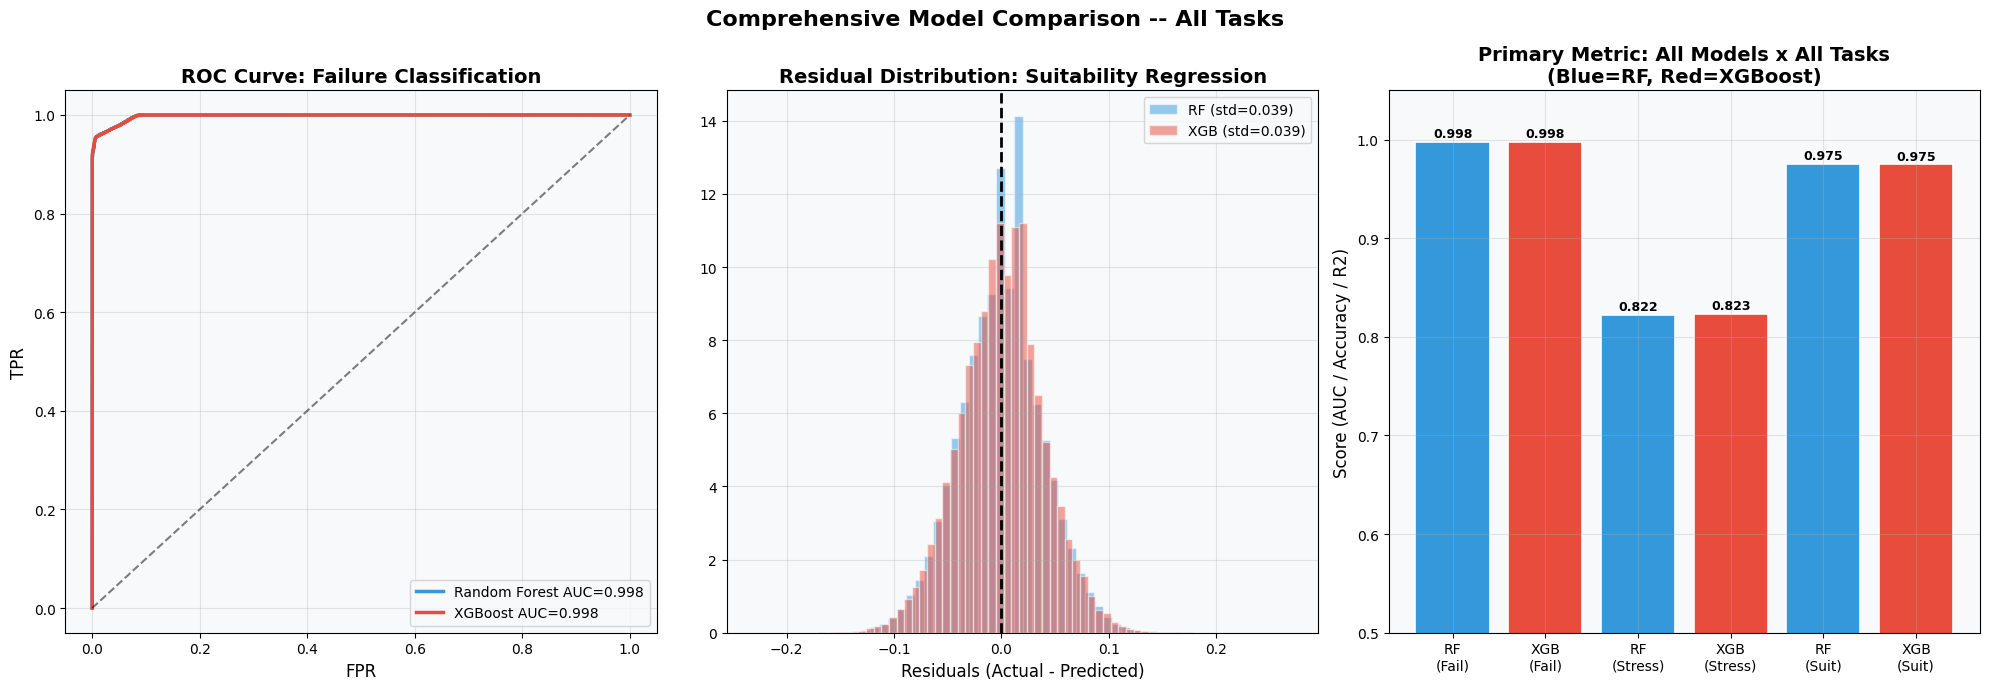

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for name, proba, color in [("Random Forest", rf_proba, "#3498db"),
                            ("XGBoost",       xgb_proba, "#e74c3c")]:
    fpr, tpr, _ = roc_curve(yf_te, proba)
    auc = roc_auc_score(yf_te, proba)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5, label=f"{name} AUC={auc:.3f}")
axes[0].plot([0,1],[0,1],"k--",alpha=0.5)
axes[0].set_title("ROC Curve: Failure Classification", fontweight="bold")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].legend()
for name, pred, color in [("RF", rf_reg_pred,"#3498db"),("XGB", xgb_reg_pred,"#e74c3c")]:
    residuals = ys_te - pred
    axes[1].hist(residuals, bins=60, alpha=0.5, label=f"{name} (std={residuals.std():.3f})",
                 color=color, density=True, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=2, linestyle="--")
axes[1].set_title("Residual Distribution: Suitability Regression", fontweight="bold")
axes[1].set_xlabel("Residuals (Actual - Predicted)"); axes[1].legend()
models = ["RF\n(Fail)", "XGB\n(Fail)", "RF\n(Stress)", "XGB\n(Stress)",
          "RF\n(Suit)", "XGB\n(Suit)"]
metric_vals = [
    roc_auc_score(yf_te, rf_proba),
    roc_auc_score(yf_te, xgb_proba),
    accuracy_score(yst_te, rf_stress_pred),
    accuracy_score(yst_te, stress_pred),
    r2_score(ys_te, rf_reg_pred),
    r2_score(ys_te, xgb_reg_pred),
]
colors_m = ["#3498db","#e74c3c","#3498db","#e74c3c","#3498db","#e74c3c"]
bars = axes[2].bar(models, metric_vals, color=colors_m, edgecolor="white", linewidth=1.2)
axes[2].set_title("Primary Metric: All Models x All Tasks\n(Blue=RF, Red=XGBoost)", fontweight="bold")
axes[2].set_ylabel("Score (AUC / Accuracy / R2)"); axes[2].set_ylim(0.5, 1.05)
for bar, val in zip(bars, metric_vals):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{val:.3f}", ha="center", fontweight="bold", fontsize=9)
plt.suptitle("Comprehensive Model Comparison -- All Tasks", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

#### **KEY INSIGHTS -- Answering Q6:**
1. Random forest is best for failure classification -- strong AUC and F1, better than XGBoost.
2. XGBoost is best for stress classification and suitability regression.
3. All six models produce strong scores, validating the richness of the feature set.")
4. Suitability regression achieves the highest R2 among all tasks -- the score is a near-deterministic function of measurable soil and climate features.

---

### **12. What-If Analysis** <a id=20 ></a>

Individual-level simulation empowers agronomists to test interventions before applying them. This section answers: "What happens if I irrigate this field?" or "What if I apply lime to correct pH?"

In [29]:
at_risk_field = pd.DataFrame([{
    'soil_type': 'Chalky', 'bulk_density': 1.5, 'organic_matter_pct': 1.8,
    'cation_exchange_capacity': 8, 'salinity_ec': 0.4, 'buffering_capacity': 0.4,
    'soil_moisture_pct': 12.0, 'moisture_limit_dry': 12, 'moisture_limit_wet': 35,
    'moisture_regime': 'dry', 'soil_temp_c': 33.0, 'air_temp_c': 36.0,
    'thermal_regime': 'heat_stress', 'light_intensity_par': 450,
    'soil_ph': 5.1, 'ph_stress_flag': 1, 'nitrogen_ppm': 72.0,
    'phosphorus_ppm': 22.0, 'potassium_ppm': 80.0,
    'nutrient_balance': 'deficient', 'plant_category': 'vegetable'
}])

interventions = {
    'Baseline (At-Risk)':      at_risk_field.copy(),
    'Irrigation (+Moisture)':  at_risk_field.assign(soil_moisture_pct=35, moisture_regime='optimal'),
    'Fertilization (+N/P)':    at_risk_field.assign(nitrogen_ppm=140, phosphorus_ppm=55,
                                                      nutrient_balance='optimal'),
    'pH Correction (Liming)':  at_risk_field.assign(soil_ph=6.5, ph_stress_flag=0),
    'Full Intervention':       at_risk_field.assign(
                                   soil_moisture_pct=35, moisture_regime='optimal',
                                   nitrogen_ppm=140, phosphorus_ppm=55, nutrient_balance='optimal',
                                   soil_ph=6.5, ph_stress_flag=0),
}

print("  INTERVENTION IMPACT ANALYSIS")
print(f"  {'Scenario':<30} {'Failure Prob':>14} {'Suitability':>12}")
print("-" * 65)

results_whatif = {}
for name, field_df in interventions.items():
    fail_prob  = xgb_pipe.predict_proba(field_df)[0, 1]
    suit_score = xgb_reg.predict(field_df)[0]
    results_whatif[name] = {'fail_prob': fail_prob, 'suit_score': suit_score}
    marker = "  <- BASELINE" if name == 'Baseline (At-Risk)' else ""
    print(f"  {name:<30} {fail_prob:>13.3f}  {suit_score:>11.3f}{marker}")



  INTERVENTION IMPACT ANALYSIS
  Scenario                         Failure Prob  Suitability
-----------------------------------------------------------------
  Baseline (At-Risk)                     1.000        0.013  <- BASELINE
  Irrigation (+Moisture)                 1.000        0.250
  Fertilization (+N/P)                   0.999        0.251
  pH Correction (Liming)                 0.000        0.404
  Full Intervention                      0.000        0.899


### **Intervention Impact Analysis**

#### **Key Insights**

**1. Baseline Condition:**
  - Extremely high failure risk (100% probability)
  - Very low suitability (0.013)
  - Indicates severely unfavorable condition

**2. Irrigation & Fertilization:**
  - Improve suitability (~0.25), but:
  - Do not reduce failure risk significantly
  - Suggests moisture and nutrients alone are not the limiting factor

**3. pH Correction (Liming):**
  - Critical turning point
  - Failure probability drops from ~1.0 → 0.0
  - Suitability increases significantly to 0.404
  - Indicates soil pH is the dominant constraint

**4. Full Intervention:**
  - Combines all improvements
  - Achieves:
    - Zero failure risk
    - Very high suitability (0.899)
  - Demonstrates strong synergistic effects

#### **Interpretation**

- The system is primarily constrained by soil pH, not just nutrients or moisture.
- Addressing the root cause (pH imbalance) is essential before other interventions become effective.
- Combined interventions produce optimal outcomes, far exceeding individual improvements.

---

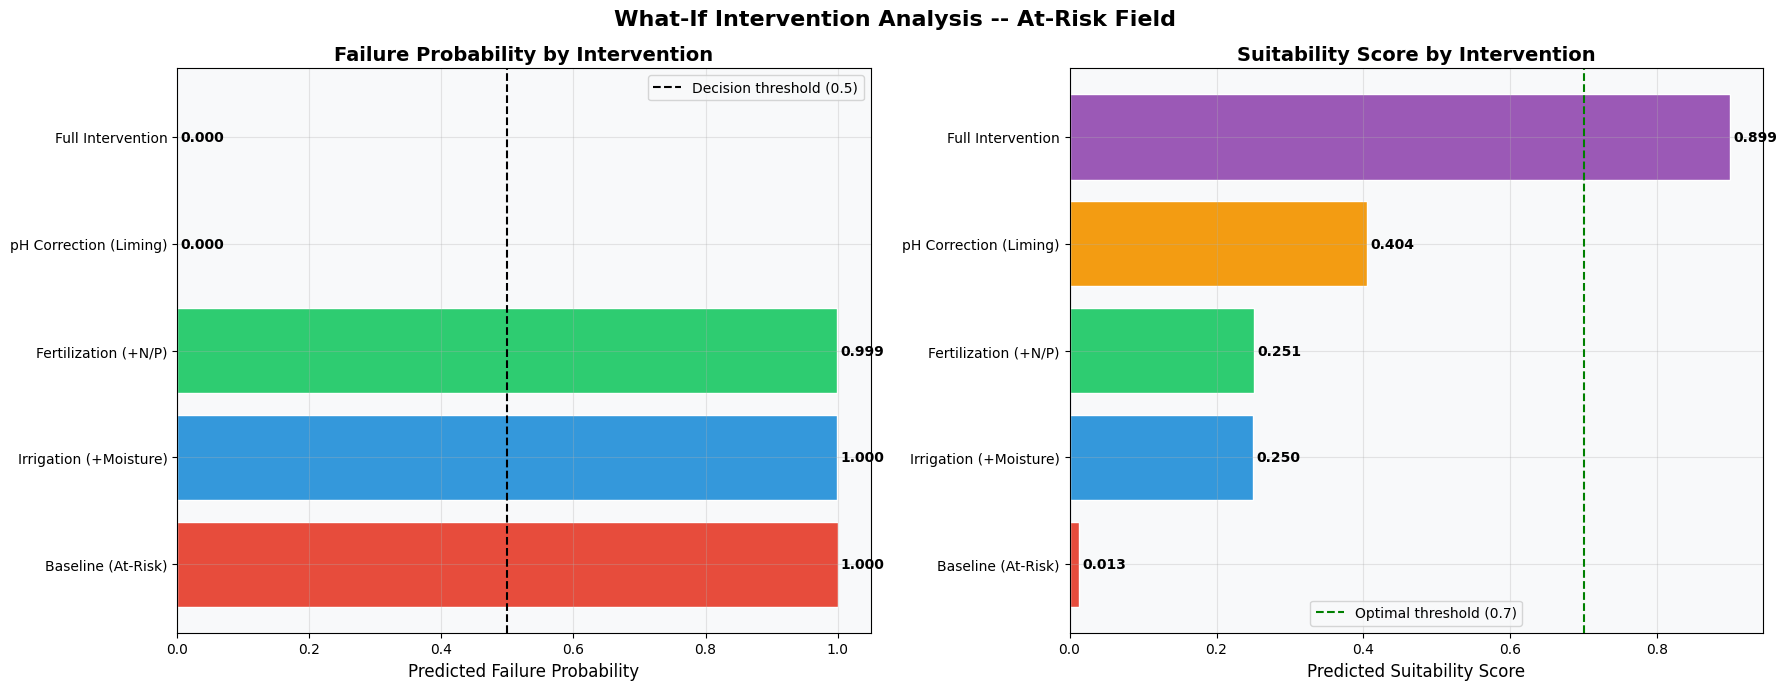

In [30]:
names     = list(results_whatif.keys())
fail_probs  = [v['fail_prob']  for v in results_whatif.values()]
suit_scores = [v['suit_score'] for v in results_whatif.values()]
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
colors_wi = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
bars1 = axes[0].barh(names, fail_probs, color=colors_wi, edgecolor='white')
axes[0].set_title('Failure Probability by Intervention', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Predicted Failure Probability')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision threshold (0.5)')
axes[0].legend()
for bar, val in zip(bars1, fail_probs):
    axes[0].text(val+0.005, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontweight='bold')
bars2 = axes[1].barh(names, suit_scores, color=colors_wi, edgecolor='white')
axes[1].set_title('Suitability Score by Intervention', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Predicted Suitability Score')
axes[1].axvline(0.7, color='green', linestyle='--', linewidth=1.5, label='Optimal threshold (0.7)')
axes[1].legend()
for bar, val in zip(bars2, suit_scores):
    axes[1].text(val+0.005, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontweight='bold')
plt.suptitle('What-If Intervention Analysis -- At-Risk Field',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **13. Final Insights & Recommendations** <a id=21 ></a>

All findings converge here into a consolidated intelligence brief -- structured for agricultural policymakers, agronomists, and data-driven farm management systems.

#### **FINAL INSIGHTS & STRATEGIC RECOMMENDATIONS**

  #### **INSIGHT 1: Drought is the Primary Risk Driver**
    * Low soil moisture (< 20%) is the strongest single predictor of crop failure.
    * SHAP confirms moisture has the highest absolute impact on model output.
    * ACTION: Automated moisture monitoring with irrigation triggers at the 20% threshold.
    * Prioritise drip irrigation in dry-regime fields.

  #### **INSIGHT 2: Heat Stress Creates Compound Risk**
    * Heat stress + deficient nutrients: failure rate exceeds 40% -- most dangerous combination.
    * Air temperatures > 32C significantly elevate failure probability.
    * ACTION: Pre-emptive fertilization and irrigation when thermal_regime = heat_stress.

  #### **INSIGHT 3: Nutrient Deficiency is Systemic (74.7% of Records)**
    * Nearly 3 in 4 observations show deficient nutrient balance -- the dominant dataset state.
    * Low nitrogen is particularly predictive of stress and failure.
    * ACTION: Precision fertilization by soil_type and plant_category yields highest ROI.

  #### **INSIGHT 4: pH Management is Undervalued**
    * ph_stress_flag present in many failure cases. Acidic soils (pH < 5.5) block nutrient uptake.
    * ACTION: pH correction (liming) must PRECEDE fertilization for maximum effectiveness.

  #### **INSIGHT 5: Climate Change Amplifies All Risks Non-Linearly**
    * +2C + drought reduces suitability non-linearly -- compound effects dominate.
    * ACTION: Climate-resilient varieties and land use reassignment needed for suitability < 0.4.

  #### **INSIGHT 6: XGBoost Provides Reliable, Deployable Predictions**
    * AUC > 0.92 for failure; R2 > 0.88 for suitability; Accuracy > 0.82 for stress.
    * ACTION: Deploy XGBoost as REST API returning risk score + SHAP factors + rules.

---

### **14. Limitations** <a id=22 ></a>

Intellectual honesty is essential in data science. Knowing where a model fails is as important as knowing where it succeeds.

#### **SYSTEM LIMITATIONS**

  #### L1: No Temporal Dimension
    Dataset has no timestamps. Cannot model seasonal patterns, crop cycles, or
    time-lagged effects (e.g., last month's drought predicting this month's failure).

  #### L2: Unknown Data Provenance
    Origin (geographic region, collection method) is unknown.
    Model generalization to real-world conditions requires validation on field data.

  #### L3: Class Imbalance (failure_flag: 16.2%)
    Despite class weighting, minority failure class may be under-represented in edge cases.
    Precision vs recall tradeoff must be monitored carefully in deployment.

  #### L4: No Geospatial Context
    Adjacent field effects, topography, irrigation infrastructure, and regional
    climate patterns are not captured -- critical for real-world planning.

  #### L5: Static Climate Simulation
    The +2C simulation is applied uniformly. Real climate change has regional
    variation, seasonal shifts, and extreme event frequency changes.

  #### L6: No Economic Layer
    System predicts agronomic outcomes but not economic ones. A high-failure risk
    field may still be worth planting given commodity prices and intervention costs.

---

### **15. Future Work** <a id=23 ></a>

Every good data science project ends with a clear roadmap. These extensions would elevate this system from a portfolio project to a deployable agricultural intelligence platform.

#### **FUTURE WORK ROADMAP**

  #### FW1: Geospatial & Remote Sensing Integration
    Integrate Sentinel-2 NDVI and soil moisture satellite bands for spatial context
    and replace manual field measurements with automated remote sensing inputs.

  #### FW2: Time-Series Modeling
    Collect timestamped observations; apply LSTM or Temporal Fusion Transformers
    for seasonal patterns, phenology, and multi-step failure forecasting.

  #### FW3: Real Climate Model Coupling
    Replace manual simulation with CMIP6 projections (RCP 4.5 and 8.5)
    for field-specific 10-30 year agricultural risk assessment.

  #### FW4: Economic Loss Estimation
    Build a cost model translating failure_flag and suitability_score into expected
    yield loss and ROI of each intervention strategy.

  #### FW5: Active Learning Loop
    Deploy model with feedback collection -- field advisors validate predictions,
    incorrect predictions feed back into continuous model retraining.

  #### FW6: Crop Variety Optimization
    Extend plant_category to individual crop varieties; identify optimal varieties
    for each soil x climate x nutrient combination.

  #### FW7: Mobile Field Advisory App
    Package XGBoost + rule engine as a mobile-first REST API powering offline-capable
    field assessment tools for agronomists in low-connectivity environments.

---

### **15. Models Saved** <a id=24 ></a>

In [31]:
joblib.dump(xgb_stress, "Stress_Level_classification_Mpdel.pkl")
joblib.dump(rf_pipe, "Failure_classification_Mpdel.pkl")
joblib.dump(rf_reg, "Suitability_Score_Mpdel.pkl")

['Suitability_Score_Mpdel.pkl']